<a href="https://colab.research.google.com/github/Sampavi01/Hotel_Revenue_Forecasting/blob/forecasting/ModelTraining_GridSearch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# --- Imports & Constants ---
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.linear_model import Ridge
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from datetime import timedelta
import matplotlib.pyplot as plt
import os
import itertools
import random

# Paths & scope
OUTPUT_FILE_NAME = 'Model_Training_Datasets.xlsx'
TEST_SET_DAYS = 60      # Last 2 months for final evaluation

# Optimization Constants
MAPE_EPSILON = 1e-6
MIN_TRAIN_DAYS = 180

# Targets (raw only)
TARGET_RAW_COLS = ['Revenue_By_BreakFast', 'Revenue_By_Dinner', 'Revenue_By_Lunch']

# Features
LAG_DAYS = [1, 7, 14]
ROLL_WINDOWS = [7]

# Cross-validation Defaults
N_SPLITS = 2
VAL_DAYS = 90

# Storage
test_predictions_list = []
feature_importance_dict = {}
cv_results_list = []
gs_final_comparison_results = [] # Storage for final parameter comparison

In [2]:
# --- Utility Functions (Identical to Script A) ---
# [Insert Utility Functions: add_lag_and_rolling, dynamic_weights, plot_test_results, plot_residuals_over_time, plot_cv_rmse_comparison]
# (These functions must be included here for the script to run)

def add_lag_and_rolling(df, target_cols, lag_days, roll_windows):
    """Adds lag and rolling features for target columns."""
    for col in target_cols:
        for lag in lag_days:
            df[f'{col}_lag{lag}'] = df[col].shift(lag)
        if pd.api.types.is_numeric_dtype(df[col]):
            for w in roll_windows:
                df[f'{col}_rollmean{w}'] = df[col].rolling(window=w, min_periods=1).mean().shift(1)
                df[f'{col}_rollstd{w}'] = df[col].rolling(window=w, min_periods=1).std().shift(1).fillna(0)
    df.fillna(0, inplace=True)
    return df

def dynamic_weights(y_val_raw, y_pred_xgb, y_pred_ridge):
    """Computes fold-specific ensemble weights via validation RMSE."""
    rmse_xgb = np.sqrt(mean_squared_error(y_val_raw, y_pred_xgb))
    rmse_ridge = np.sqrt(mean_squared_error(y_val_raw, y_pred_ridge))
    total = rmse_xgb + rmse_ridge if (rmse_xgb + rmse_ridge) > 0 else 1.0
    w_xgb = 1 - (rmse_xgb / total)
    w_ridge = 1 - w_xgb
    return w_xgb, w_ridge

def plot_test_results(test_df, center_name, meal_period):
    """Plots actual vs. predicted revenue for the test set."""
    plt.figure(figsize=(12, 6))
    plt.plot(test_df['Date'], test_df['Actual_Revenue'], label='Actual Revenue', marker='o', linestyle='-')
    plt.plot(test_df['Date'], test_df['Predicted_Revenue'], label='Predicted Revenue', marker='x', linestyle='--')
    plt.title(f'Actual vs. Predicted Revenue (Test Set) - {center_name} - {meal_period}')
    plt.xlabel('Date'); plt.ylabel('Revenue')
    plt.legend(); plt.grid(True, alpha=0.5); plt.xticks(rotation=45)
    plt.tight_layout(); plt.show()

def plot_residuals_over_time(residuals_df, center_name, meal_period):
    """Plots the residuals (Actual - Predicted) over the test time period."""
    residuals_df = residuals_df.copy()
    residuals_df['Residual'] = residuals_df['Actual_Revenue'] - residuals_df['Predicted_Revenue']
    plt.figure(figsize=(12, 5))
    plt.plot(residuals_df['Date'], residuals_df['Residual'], marker='.', linestyle='None', alpha=0.6)
    plt.axhline(0, color='red', linestyle='--', linewidth=1)
    mean_residual = residuals_df['Residual'].mean()
    plt.axhline(mean_residual, color='blue', linestyle='-', linewidth=1, label=f'Mean Residual: {mean_residual:.2f}')
    plt.title(f'Test Set Residuals Over Time - {center_name} - {meal_period}')
    plt.xlabel('Date'); plt.ylabel('Residual (Actual - Predicted)')
    plt.legend(); plt.grid(True, alpha=0.5); plt.xticks(rotation=45)
    plt.tight_layout(); plt.show()

def plot_cv_rmse_comparison(cv_results_list):
    """Compares the RMSE for all folds across all centers/meals for robustness check."""
    df_cv = pd.DataFrame(cv_results_list)
    if df_cv.empty:
        print("No CV results to plot.")
        return
    df_cv['Center_Meal'] = df_cv['Center'].astype(str) + ' - ' + df_cv['Meal']
    df_pivot = df_cv.pivot(index='Center_Meal', columns='Fold', values='RMSE')
    plt.figure(figsize=(14, 7))
    df_pivot.plot(kind='bar', figsize=(14, 7), width=0.8)
    plt.title('Fold-by-Fold RMSE Comparison Across All Models')
    plt.ylabel('RMSE (Raw Scale)')
    plt.xlabel('Revenue Center - Meal Period')
    plt.xticks(rotation=45, ha='right'); plt.legend(title='CV Fold')
    plt.grid(axis='y', alpha=0.5); plt.tight_layout(); plt.show()

In [3]:
# --- 1. Scoring Function for Grid Search (Minimizes RMSE) ---

def score_ensemble_gs(params, X_train_full, Y_train_full, tscv, raw_target_col, numeric_features, categorical_features):
    """
    Runs the Time Series Cross-Validation for a given set of hyperparameters
    and returns the average ensemble RMSE.
    """
    lr, md, alpha = params

    current_xgb_params = {
        'objective': 'reg:squarederror',
        'learning_rate': lr,
        'max_depth': md,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'seed': 42
    }
    current_ridge_alpha = alpha
    fold_rmses = []

    for train_idx, val_idx in tscv.split(X_train_full):

        X_train_cv, X_val = X_train_full.iloc[train_idx], X_train_full.iloc[val_idx]
        Y_train_cv, Y_val = Y_train_full.iloc[train_idx][raw_target_col], Y_train_full.iloc[val_idx][raw_target_col]

        scaler = StandardScaler()
        X_train_num = pd.DataFrame(scaler.fit_transform(X_train_cv[numeric_features]), columns=numeric_features, index=X_train_cv.index)
        X_val_num = pd.DataFrame(scaler.transform(X_val[numeric_features]), columns=numeric_features, index=X_val.index)
        X_train_cv_scaled = pd.concat([X_train_num, X_train_cv[categorical_features]], axis=1)
        X_val_scaled = pd.concat([X_val_num, X_val[categorical_features]], axis=1)

        dtrain = xgb.DMatrix(X_train_cv_scaled.values, label=Y_train_cv, feature_names=list(X_train_cv_scaled.columns))
        dval = xgb.DMatrix(X_val_scaled.values, label=Y_val, feature_names=list(X_val_scaled.columns))

        es_xgb_model = xgb.train(
            current_xgb_params,
            dtrain,
            num_boost_round=5000,
            evals=[(dval, 'validation')],
            early_stopping_rounds=100,
            verbose_eval=False
        )
        y_pred_xgb = es_xgb_model.predict(dval)

        best_ridge_model = Ridge(alpha=current_ridge_alpha, random_state=42).fit(X_train_cv_scaled, Y_train_cv)
        y_pred_ridge = best_ridge_model.predict(X_val_scaled)

        w_xgb, w_ridge = dynamic_weights(Y_val, y_pred_xgb, y_pred_ridge)
        y_pred_val_ens = (w_xgb * y_pred_xgb) + (w_ridge * y_pred_ridge)
        rmse = np.sqrt(mean_squared_error(Y_val, y_pred_val_ens))
        fold_rmses.append(rmse)

    return np.mean(fold_rmses)

In [4]:
# --- 2. Main Training Function (Grid Search Optimized) ---

def train_and_forecast_center(df_center, center_name):
    """
    Runs feature engineering, dynamic CV setup, Grid Search (restrictive),
    and final test evaluation using the best parameters.
    """
    df_center = add_lag_and_rolling(df_center, TARGET_RAW_COLS, LAG_DAYS, ROLL_WINDOWS)
    max_date = df_center['Date'].max()
    test_start_date = max_date - timedelta(days=TEST_SET_DAYS)
    df_train_full = df_center[df_center['Date'] < test_start_date].copy()
    df_test_full = df_center[df_center['Date'] >= test_start_date].copy()

    if df_train_full.empty or df_test_full.empty:
        print(f"ERROR: Center {center_name} data is insufficient for split.")
        return

    data_length = len(df_train_full)
    if data_length < (MIN_TRAIN_DAYS + VAL_DAYS * N_SPLITS):
        new_val_days = max(15, int(data_length * 0.1))
        new_n_splits = max(1, int((data_length - new_val_days) / MIN_TRAIN_DAYS))
        tscv = TimeSeriesSplit(n_splits=new_n_splits, test_size=new_val_days)
        print(f"⚠️ Adjusted CV for small data ({center_name}): n_splits={new_n_splits}, test_size={new_val_days}")
    else:
        tscv = TimeSeriesSplit(n_splits=N_SPLITS, test_size=VAL_DAYS)

    feature_cols = [c for c in df_center.columns if c not in ['Date'] + TARGET_RAW_COLS]
    numeric_features = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_center[c])]
    categorical_features = [c for c in feature_cols if c not in numeric_features]
    X_train_full = df_train_full[feature_cols]
    Y_train_full = df_train_full[TARGET_RAW_COLS]

    # --- GRID SEARCH PARAMETER DEFINITION ---
    gs_xgb_params_grid = {
        'learning_rate': [0.005, 0.01],
        'max_depth': [3, 5],
    }
    gs_ridge_alphas = [0.01, 0.1, 1.0, 10.0, 100.0, 500.0]

    gs_param_combinations = list(itertools.product(
        gs_xgb_params_grid['learning_rate'],
        gs_xgb_params_grid['max_depth'],
        gs_ridge_alphas
    ))

    # Randomly sample to keep runtime manageable for testing (up to 4 sets)
    if len(gs_param_combinations) > 4:
        random.seed(42) # Ensure consistent sampling
        random.shuffle(gs_param_combinations)
        gs_param_combinations = gs_param_combinations[:4]

    for raw_target_col in TARGET_RAW_COLS:
        meal_period = raw_target_col.replace('Revenue_By_', '')

        print(f"\n⚙️ Starting Grid Search (Restrictive) for {center_name} - {meal_period}")

        best_gs_rmse = float('inf')
        best_gs_params = None

        # --- GRID SEARCH LOOP ---
        for params in gs_param_combinations:
            current_rmse = score_ensemble_gs(
                params, X_train_full, Y_train_full, tscv, raw_target_col, numeric_features, categorical_features
            )
            if current_rmse < best_gs_rmse:
                best_gs_rmse = current_rmse
                best_gs_params = params

        best_lr, best_md, best_alpha = best_gs_params

        print(f"✅ Best parameters found: LR={best_lr:.5f}, MD={best_md}, Alpha={best_alpha:.2f}. Min Avg CV RMSE: {best_gs_rmse:.2f}")

        gs_final_comparison_results.append({
            'Center': center_name, 'Meal': meal_period, 'Method': 'Grid Search',
            'Best_LR': best_lr, 'Best_MD': best_md, 'Best_Alpha': best_alpha,
            'Avg_CV_RMSE': best_gs_rmse
        })

        # --- Final Retraining and Evaluation (using best GS parameters) ---
        last_model_xgb = None
        last_weights = (0.5, 0.5)

        for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_full)):
            # ... (CV split, scaling, model training steps are identical to score_ensemble_gs) ...
            X_train_cv, X_val = X_train_full.iloc[train_idx], X_train_full.iloc[val_idx]
            Y_train_cv, Y_val = Y_train_full.iloc[train_idx][raw_target_col], Y_train_full.iloc[val_idx][raw_target_col]

            scaler = StandardScaler()
            X_train_num = pd.DataFrame(scaler.fit_transform(X_train_cv[numeric_features]), columns=numeric_features, index=X_train_cv.index)
            X_val_num = pd.DataFrame(scaler.transform(X_val[numeric_features]), columns=numeric_features, index=X_val.index)
            X_train_cv_scaled = pd.concat([X_train_num, X_train_cv[categorical_features]], axis=1)
            X_val_scaled = pd.concat([X_val_num, X_val[categorical_features]], axis=1)

            dtrain = xgb.DMatrix(X_train_cv_scaled.values, label=Y_train_cv, feature_names=list(X_train_cv_scaled.columns))
            dval = xgb.DMatrix(X_val_scaled.values, label=Y_val, feature_names=list(X_val_scaled.columns))

            current_xgb_params = {'objective': 'reg:squarederror', 'learning_rate': best_lr, 'max_depth': best_md, 'subsample': 0.8, 'colsample_bytree': 0.8, 'seed': 42}

            es_xgb_model = xgb.train(current_xgb_params, dtrain, num_boost_round=5000, evals=[(dval, 'validation')], early_stopping_rounds=100, verbose_eval=False)
            best_ridge_model = Ridge(alpha=best_alpha, random_state=42).fit(X_train_cv_scaled, Y_train_cv)

            if fold == tscv.n_splits - 1:
                last_model_xgb = es_xgb_model
                y_pred_xgb = es_xgb_model.predict(dval)
                y_pred_ridge = best_ridge_model.predict(X_val_scaled)
                last_weights = dynamic_weights(Y_val, y_pred_xgb, y_pred_ridge)

                y_pred_val_ens = (last_weights[0] * y_pred_xgb) + (last_weights[1] * y_pred_ridge)
                rmse = np.sqrt(mean_squared_error(Y_val, y_pred_val_ens))
                cv_results_list.append({'Center': center_name, 'Meal': meal_period, 'Fold': fold + 1, 'RMSE': rmse})

                if not f'{center_name}_{meal_period}' in feature_importance_dict:
                    fi = es_xgb_model.get_score(importance_type='weight')
                    feature_importance_dict[f'{center_name}_{meal_period}'] = pd.Series(fi).sort_values(ascending=False)

        # 6) Final model training on full data (using best iteration from CV)
        num_round = getattr(last_model_xgb, 'best_iteration', 500)
        final_scaler = StandardScaler()
        X_train_full_num = pd.DataFrame(final_scaler.fit_transform(X_train_full[numeric_features]), columns=numeric_features, index=X_train_full.index)
        X_train_final = pd.concat([X_train_full_num, df_train_full[categorical_features]], axis=1)
        dtrain_full = xgb.DMatrix(X_train_final.values, label=Y_train_full[raw_target_col], feature_names=list(X_train_final.columns))
        final_xgb_model = xgb.train(current_xgb_params, dtrain_full, num_boost_round=num_round, verbose_eval=False)
        final_ridge_model = Ridge(alpha=best_alpha, random_state=42).fit(X_train_final, Y_train_full[raw_target_col])

        # 7) Test evaluation
        X_test_num = pd.DataFrame(final_scaler.transform(df_test_full[numeric_features]), columns=numeric_features, index=df_test_full.index)
        X_test = pd.concat([X_test_num, df_test_full[categorical_features]], axis=1)
        dtest = xgb.DMatrix(X_test.values, feature_names=list(X_test.columns))
        Y_test_current = df_test_full[raw_target_col]

        y_test_xgb = final_xgb_model.predict(dtest)
        y_test_ridge = final_ridge_model.predict(X_test)
        w_xgb, w_ridge = last_weights
        y_test_ens = (w_xgb * y_test_xgb) + (w_ridge * y_test_ridge)

        test_rmse = np.sqrt(mean_squared_error(Y_test_current, y_test_ens))
        test_mape = np.mean(np.abs(Y_test_current - y_test_ens) / np.maximum(Y_test_current, MAPE_EPSILON)) * 100

        print(f"\n--- FINAL TEST SET RESULTS ({center_name} - {meal_period}) ---")
        print(f"TEST RMSE: {test_rmse:.2f}, TEST MAPE: {test_mape:.2f}%")

        plot_df = pd.DataFrame({'Date': df_test_full['Date'], 'Actual_Revenue': Y_test_current, 'Predicted_Revenue': y_test_ens})
        test_predictions_list.append(plot_df.assign(Revenue_Center=center_name, Meal_Period=meal_period))
        plot_test_results(plot_df, center_name, meal_period)
        plot_residuals_over_time(plot_df, center_name, meal_period)

--- STARTING EXECUTION: Grid Search (Restrictive Alpha) ---
✅ SUCCESS: Loaded 9 revenue centers (sheets).

⚙️ Starting Grid Search (Restrictive) for 1 - BreakFast
✅ Best parameters found: LR=0.01000, MD=3, Alpha=10.00. Min Avg CV RMSE: 885.57

--- FINAL TEST SET RESULTS (1 - BreakFast) ---
TEST RMSE: 1005.52, TEST MAPE: 570236372.00%


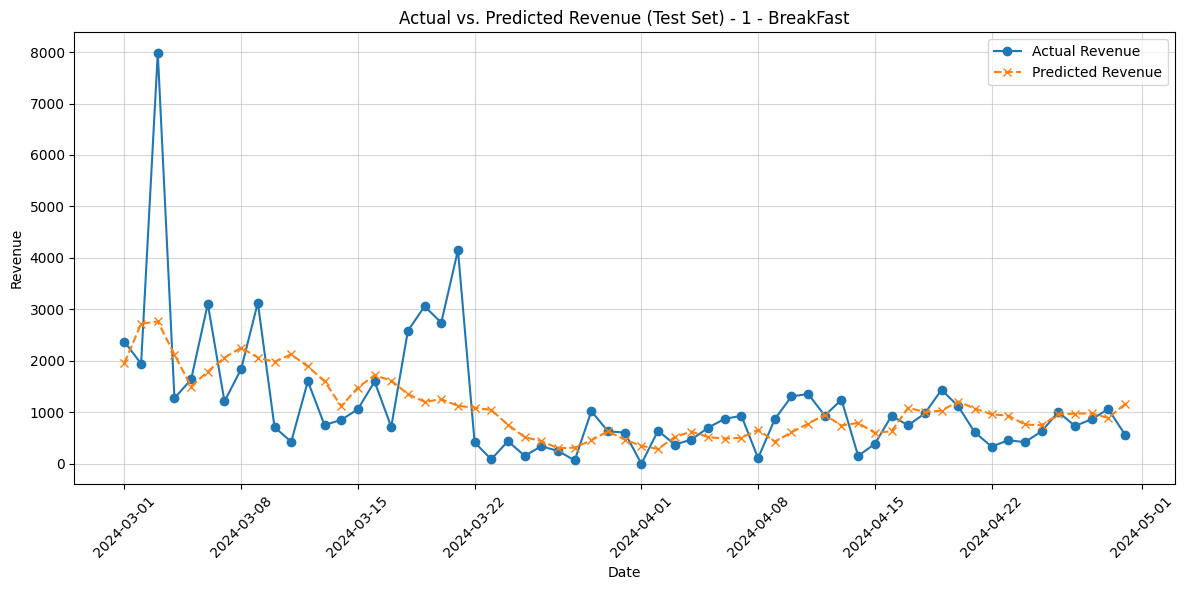

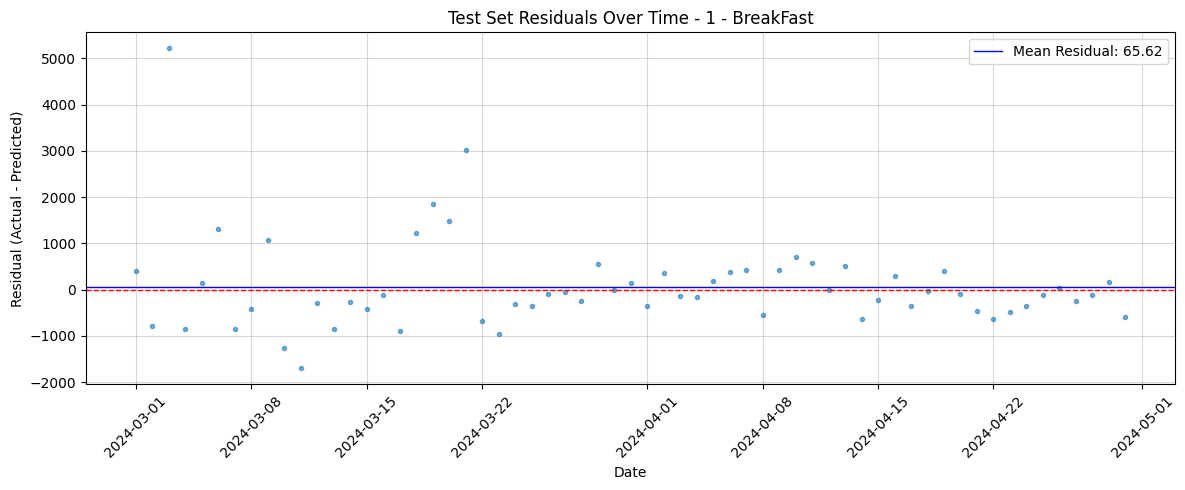


⚙️ Starting Grid Search (Restrictive) for 1 - Dinner
✅ Best parameters found: LR=0.01000, MD=3, Alpha=10.00. Min Avg CV RMSE: 1506.45

--- FINAL TEST SET RESULTS (1 - Dinner) ---
TEST RMSE: 1514.92, TEST MAPE: 61.92%


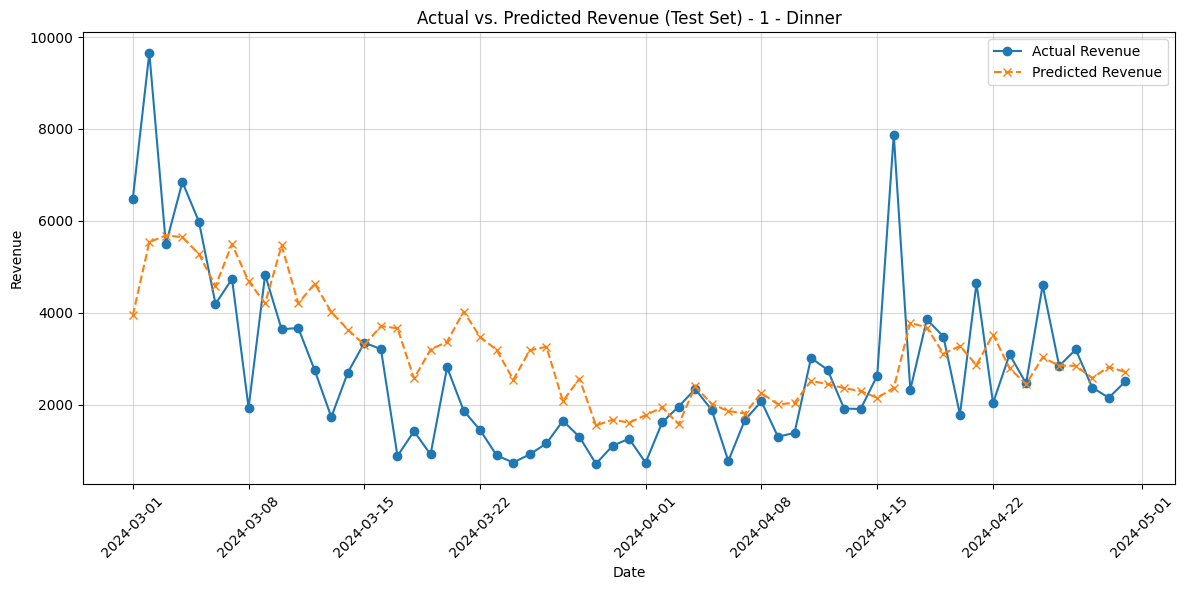

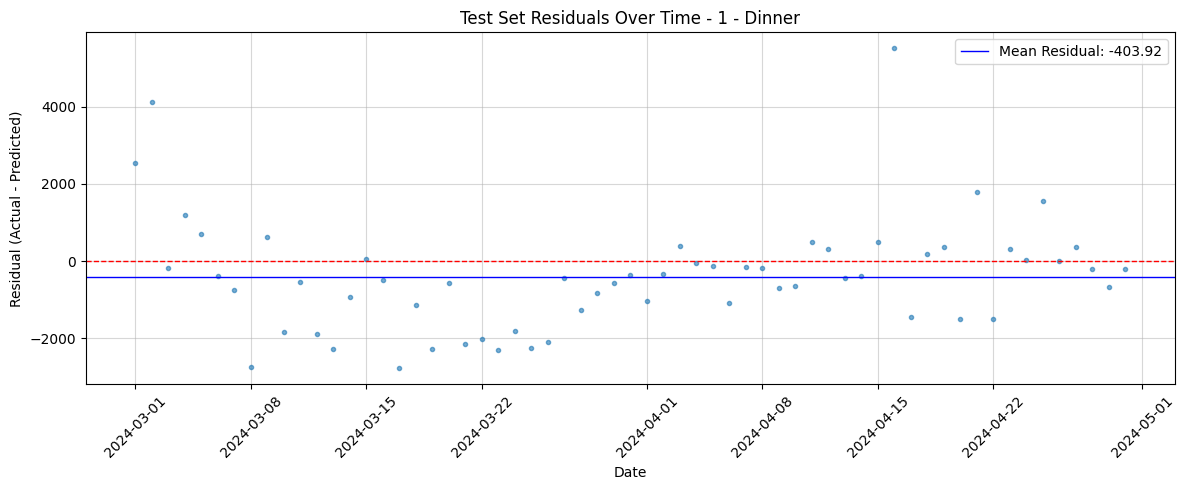


⚙️ Starting Grid Search (Restrictive) for 1 - Lunch
✅ Best parameters found: LR=0.01000, MD=5, Alpha=0.01. Min Avg CV RMSE: 781.55

--- FINAL TEST SET RESULTS (1 - Lunch) ---
TEST RMSE: 666.25, TEST MAPE: 2123549812.14%


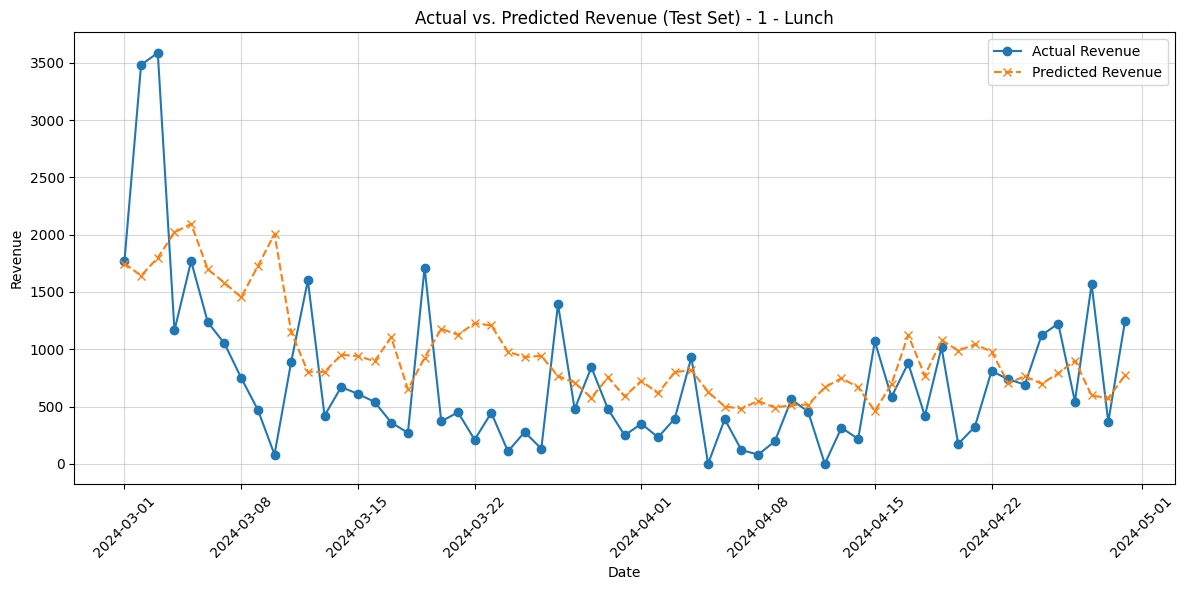

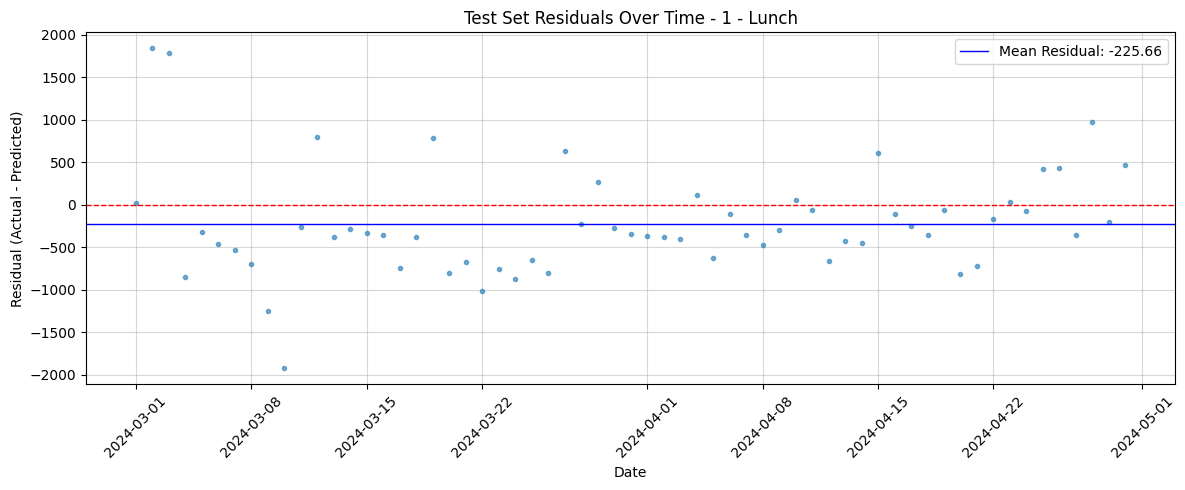


⚙️ Starting Grid Search (Restrictive) for 2 - BreakFast
✅ Best parameters found: LR=0.00500, MD=3, Alpha=500.00. Min Avg CV RMSE: 350.26

--- FINAL TEST SET RESULTS (2 - BreakFast) ---
TEST RMSE: 481.05, TEST MAPE: 10553186300.19%


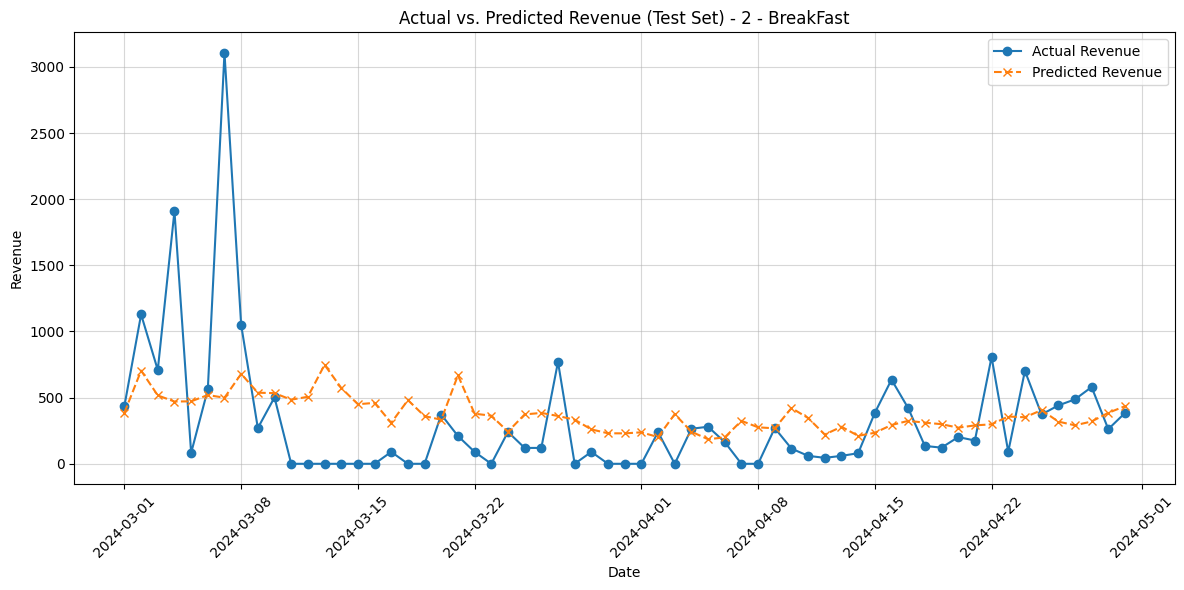

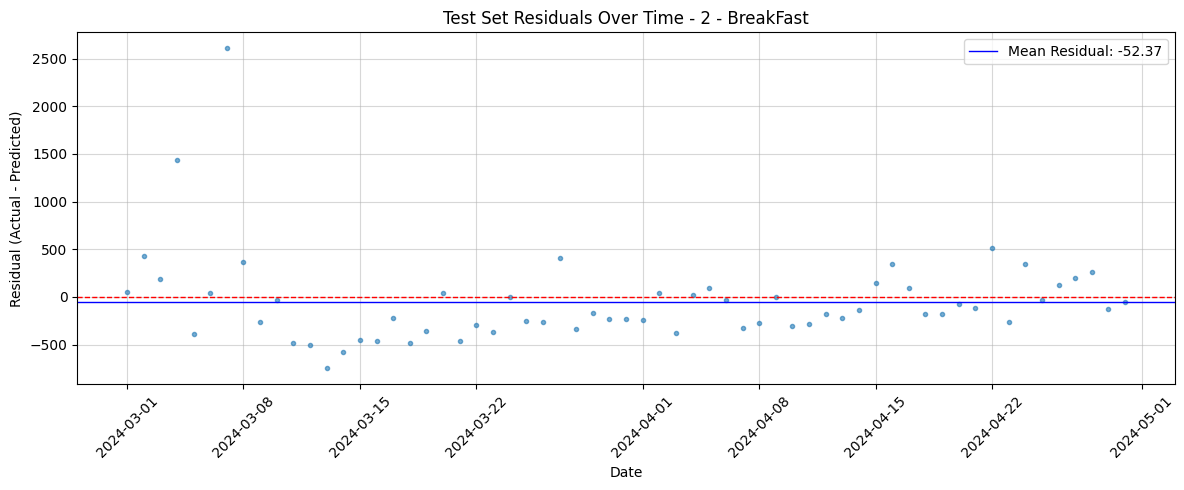


⚙️ Starting Grid Search (Restrictive) for 2 - Dinner
✅ Best parameters found: LR=0.01000, MD=3, Alpha=10.00. Min Avg CV RMSE: 872.48

--- FINAL TEST SET RESULTS (2 - Dinner) ---
TEST RMSE: 784.54, TEST MAPE: 9462266850.79%


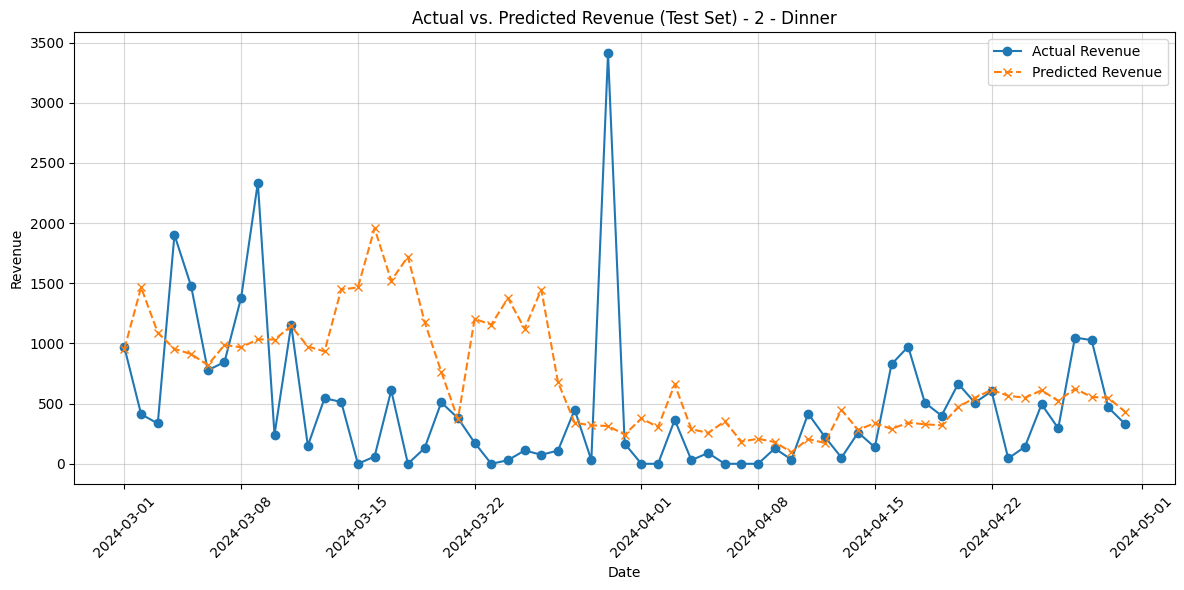

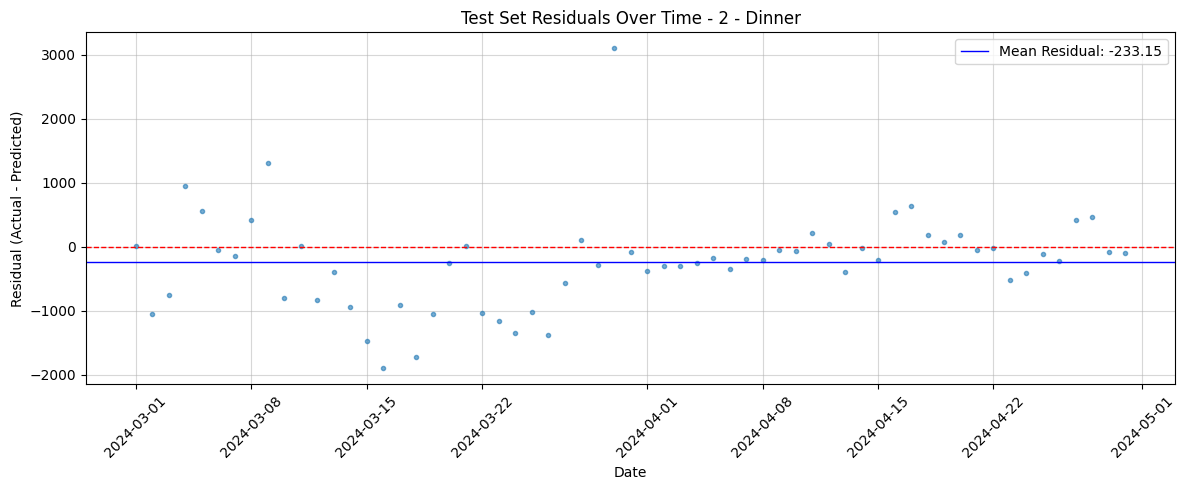


⚙️ Starting Grid Search (Restrictive) for 2 - Lunch
✅ Best parameters found: LR=0.01000, MD=3, Alpha=10.00. Min Avg CV RMSE: 421.97

--- FINAL TEST SET RESULTS (2 - Lunch) ---
TEST RMSE: 914.60, TEST MAPE: 3708996301.88%


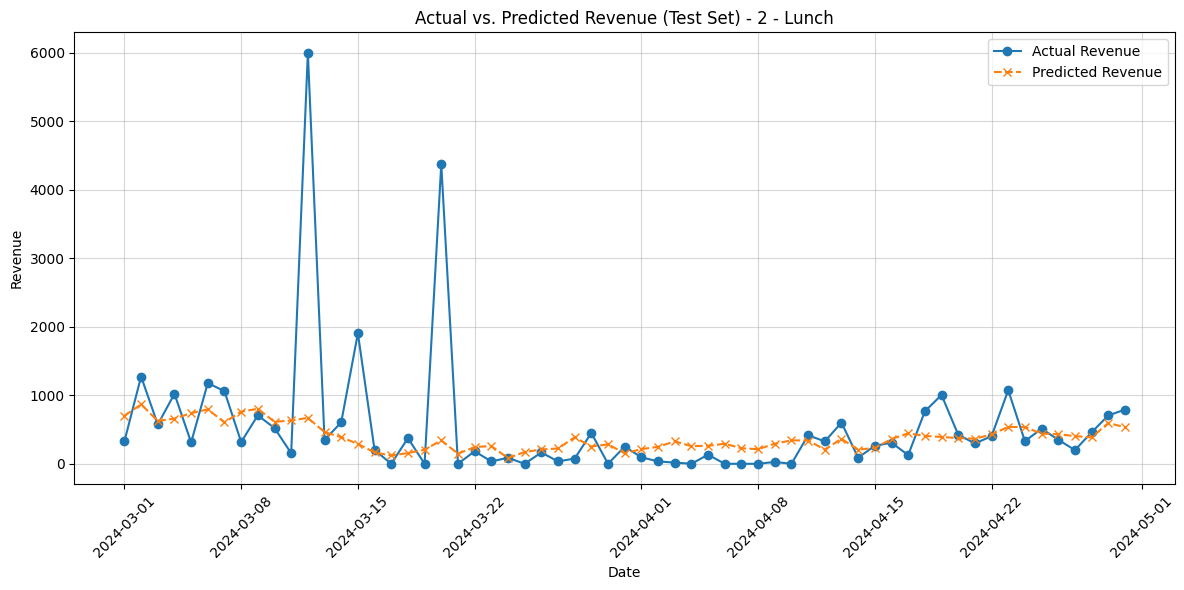

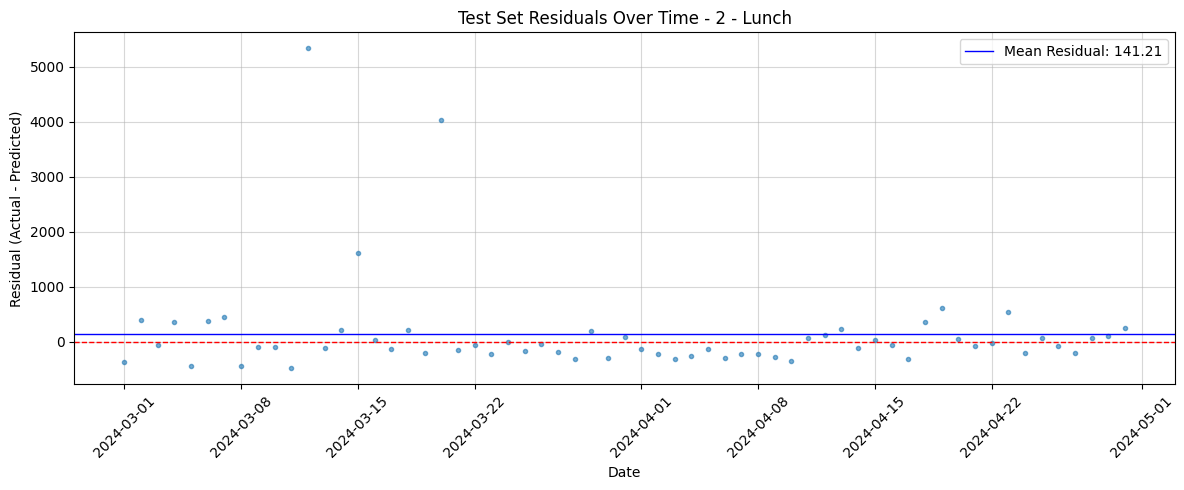


⚙️ Starting Grid Search (Restrictive) for 3 - BreakFast
✅ Best parameters found: LR=0.00500, MD=3, Alpha=500.00. Min Avg CV RMSE: 366.70

--- FINAL TEST SET RESULTS (3 - BreakFast) ---
TEST RMSE: 313.48, TEST MAPE: 8341384998.23%


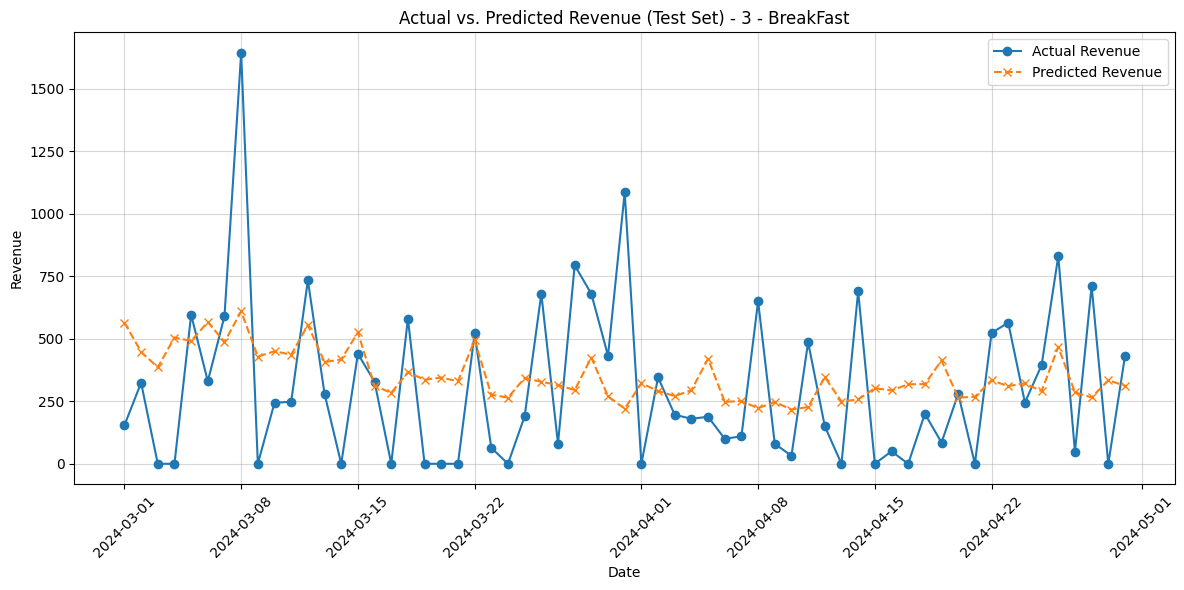

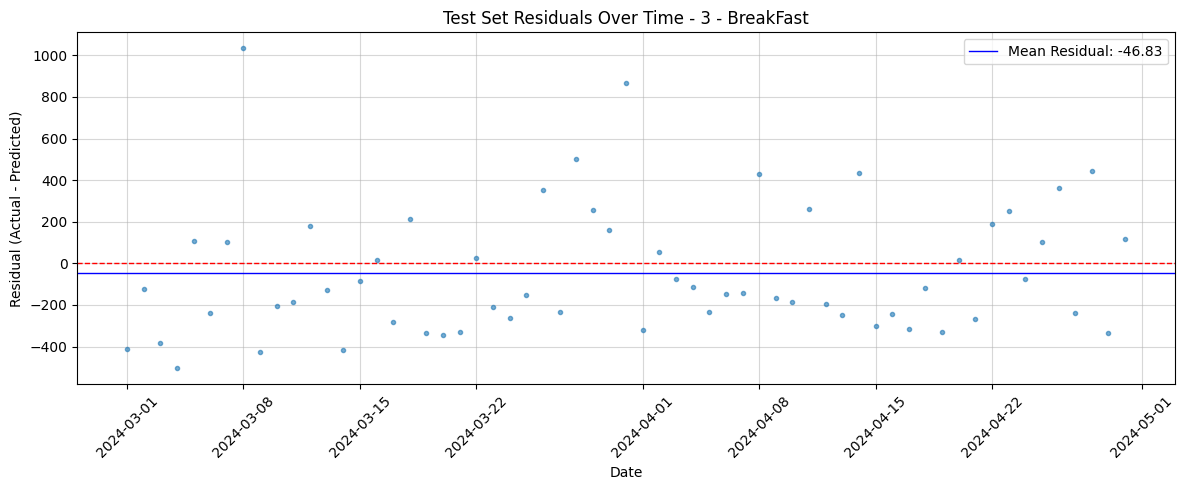


⚙️ Starting Grid Search (Restrictive) for 3 - Dinner
✅ Best parameters found: LR=0.01000, MD=5, Alpha=0.01. Min Avg CV RMSE: 4301.47

--- FINAL TEST SET RESULTS (3 - Dinner) ---
TEST RMSE: 8317.19, TEST MAPE: 40.42%


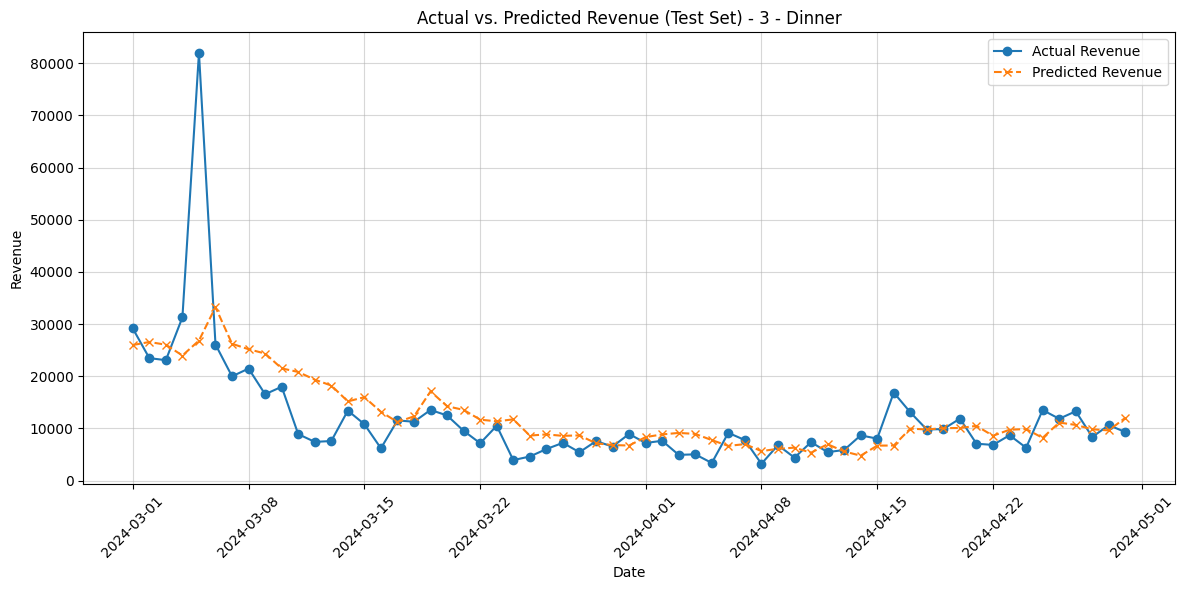

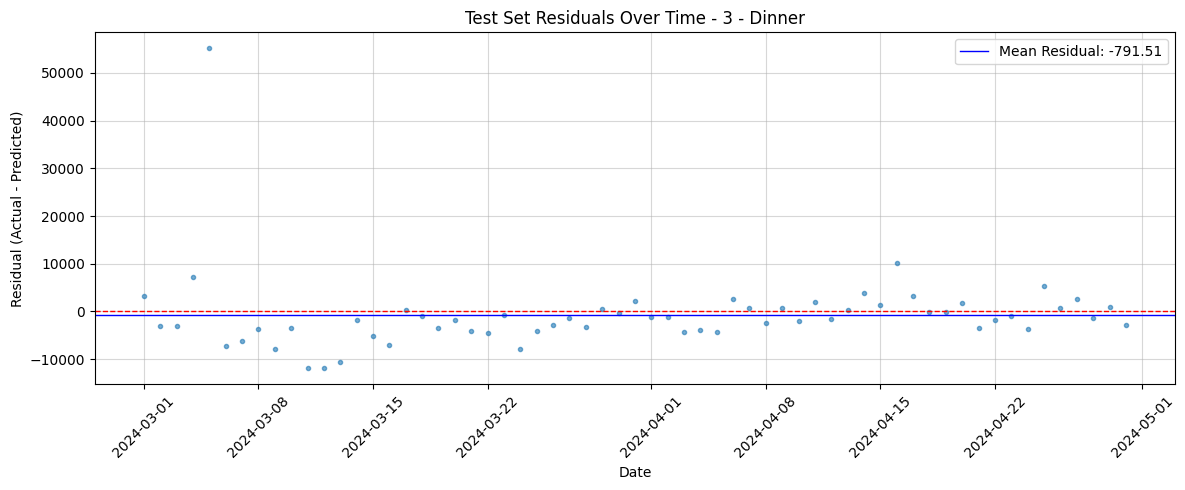


⚙️ Starting Grid Search (Restrictive) for 3 - Lunch
✅ Best parameters found: LR=0.01000, MD=5, Alpha=0.01. Min Avg CV RMSE: 1074.03

--- FINAL TEST SET RESULTS (3 - Lunch) ---
TEST RMSE: 1039.87, TEST MAPE: 47.56%


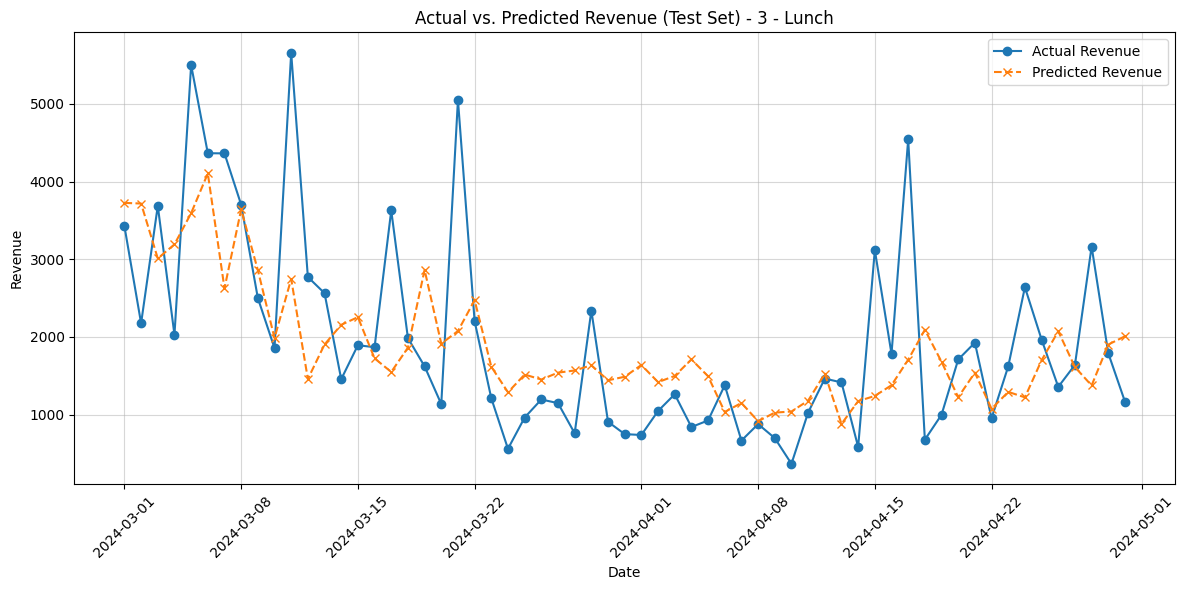

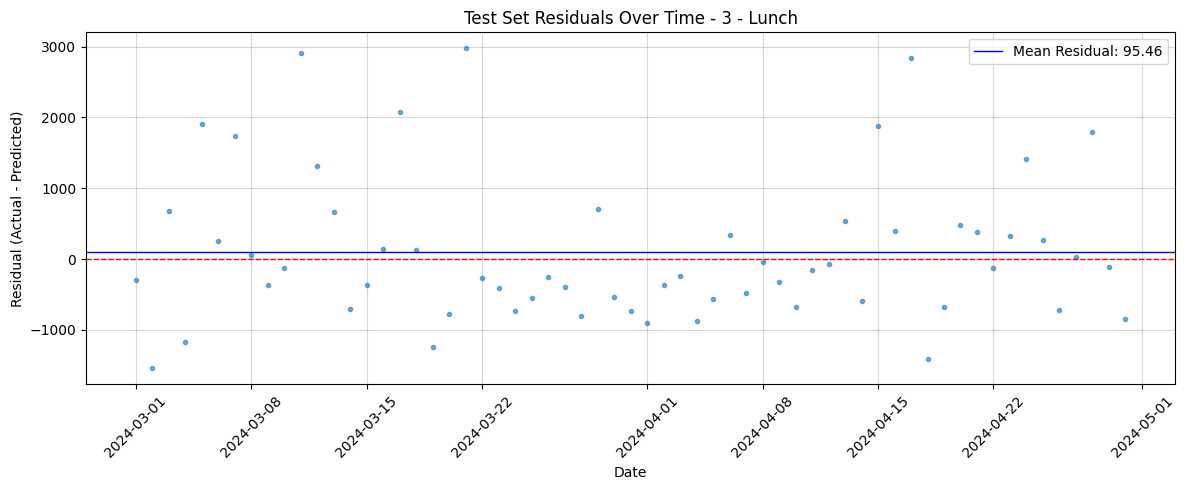


⚙️ Starting Grid Search (Restrictive) for 4 - BreakFast
✅ Best parameters found: LR=0.01000, MD=3, Alpha=10.00. Min Avg CV RMSE: 0.00

--- FINAL TEST SET RESULTS (4 - BreakFast) ---
TEST RMSE: 0.50, TEST MAPE: 50000000.00%


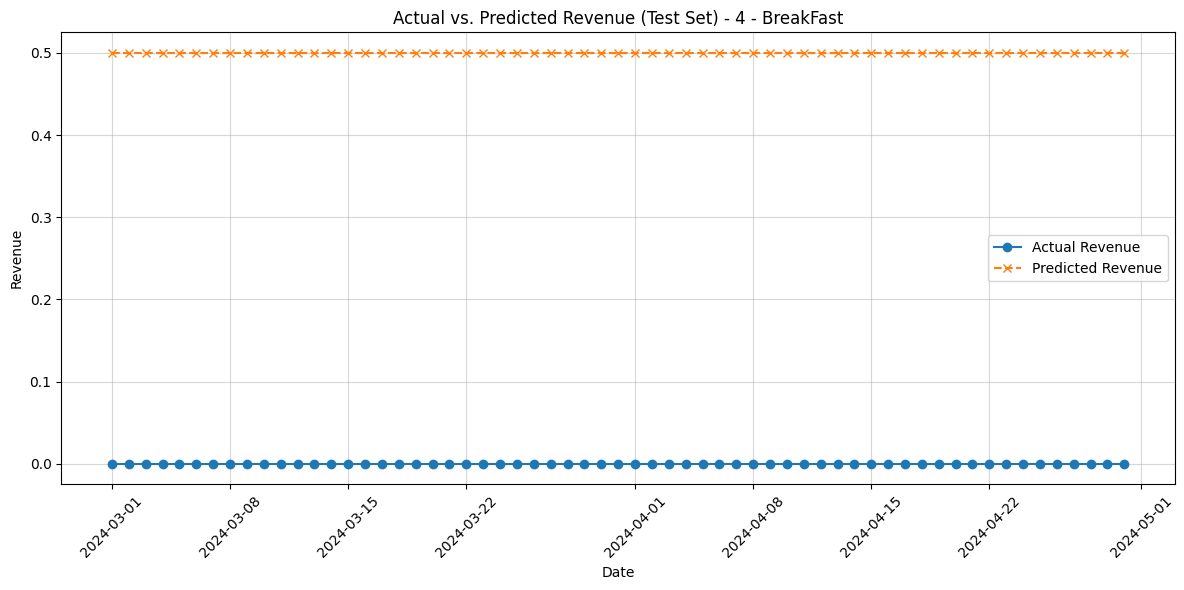

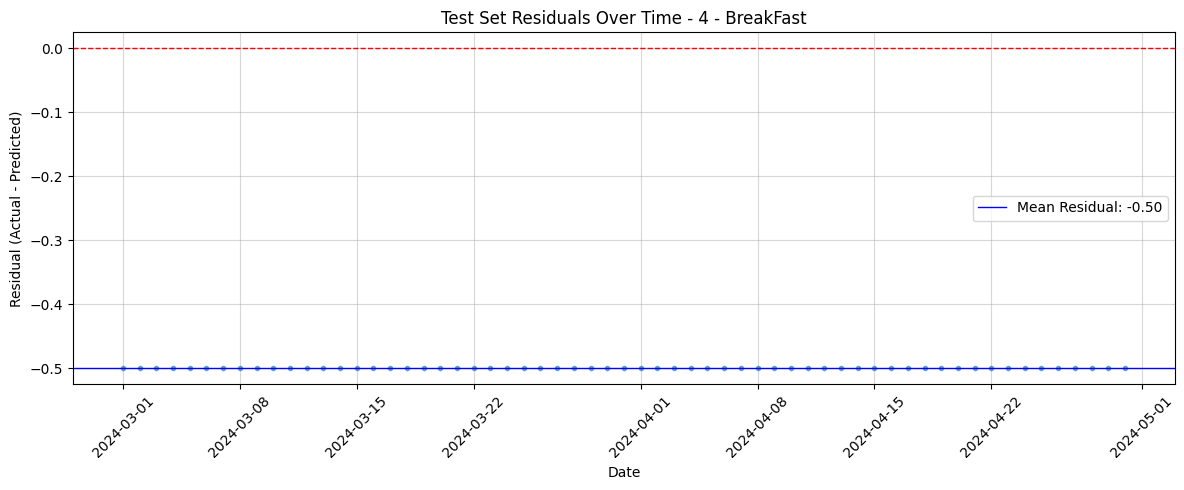


⚙️ Starting Grid Search (Restrictive) for 4 - Dinner
✅ Best parameters found: LR=0.00500, MD=3, Alpha=500.00. Min Avg CV RMSE: 0.00

--- FINAL TEST SET RESULTS (4 - Dinner) ---
TEST RMSE: 0.12, TEST MAPE: 11787604.45%


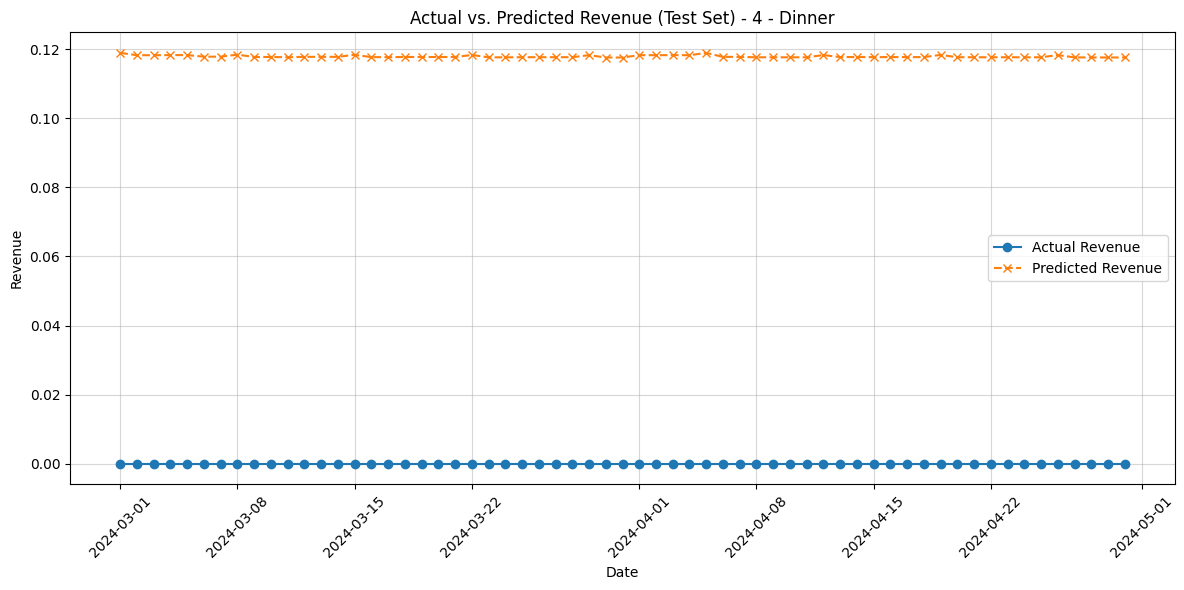

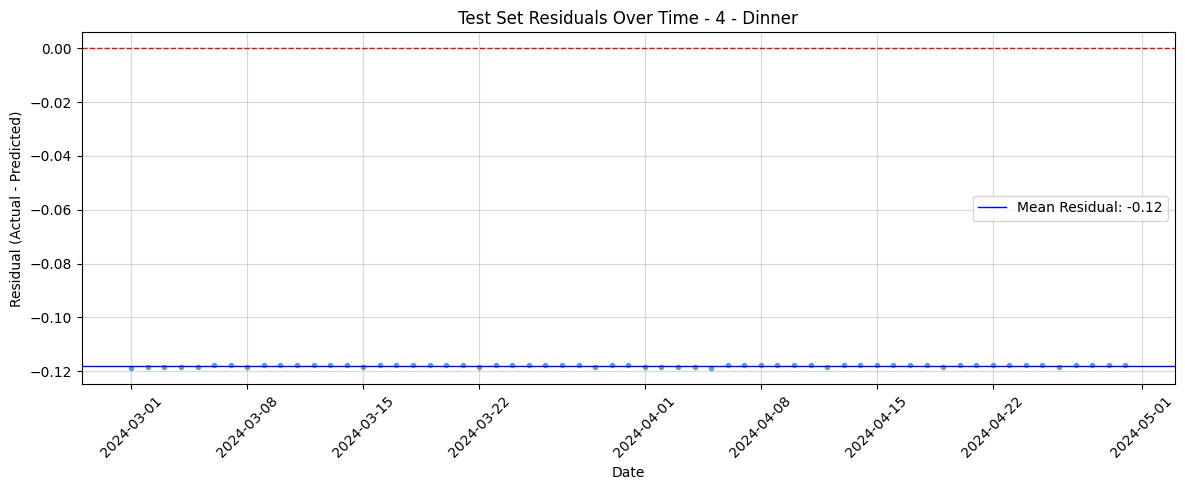


⚙️ Starting Grid Search (Restrictive) for 4 - Lunch
✅ Best parameters found: LR=0.01000, MD=3, Alpha=10.00. Min Avg CV RMSE: 0.00

--- FINAL TEST SET RESULTS (4 - Lunch) ---
TEST RMSE: 0.50, TEST MAPE: 50000000.00%


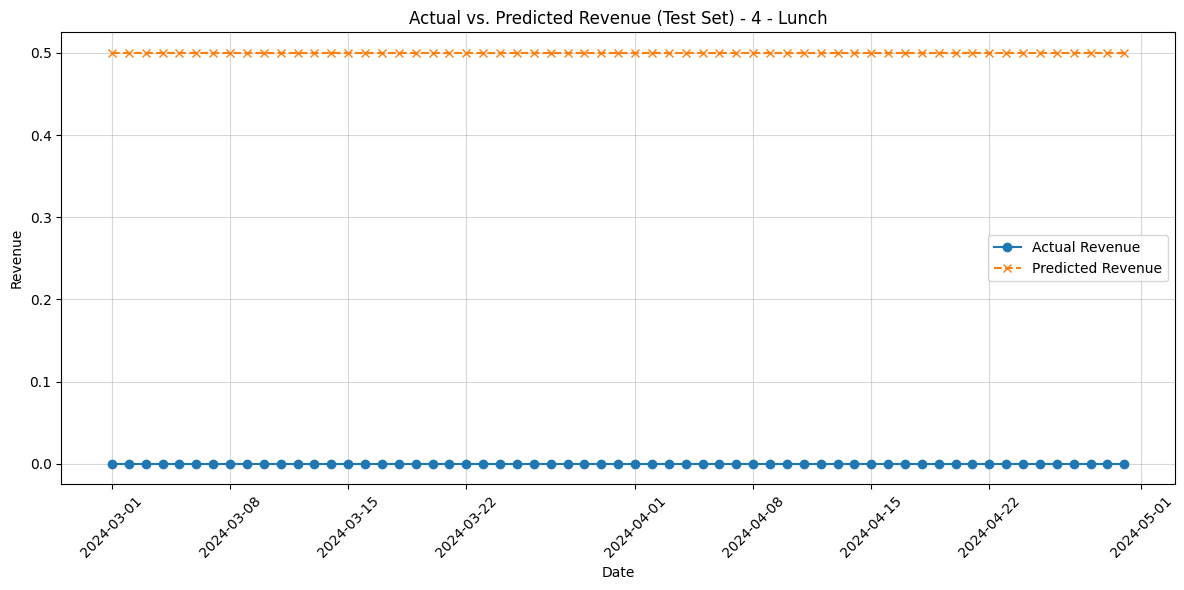

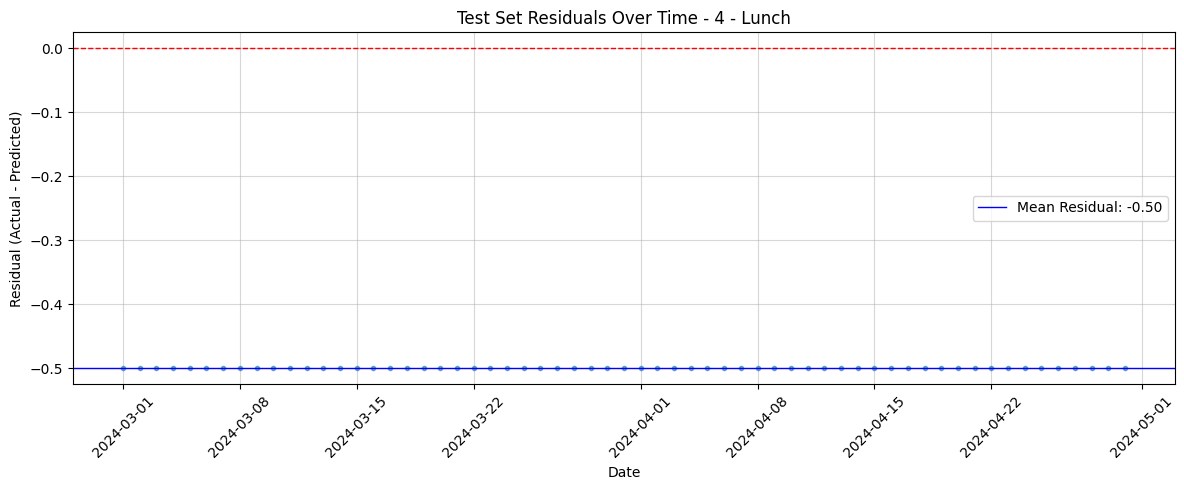


⚙️ Starting Grid Search (Restrictive) for 5 - BreakFast
✅ Best parameters found: LR=0.01000, MD=5, Alpha=0.01. Min Avg CV RMSE: 5193.68

--- FINAL TEST SET RESULTS (5 - BreakFast) ---
TEST RMSE: 2948.12, TEST MAPE: 15.62%


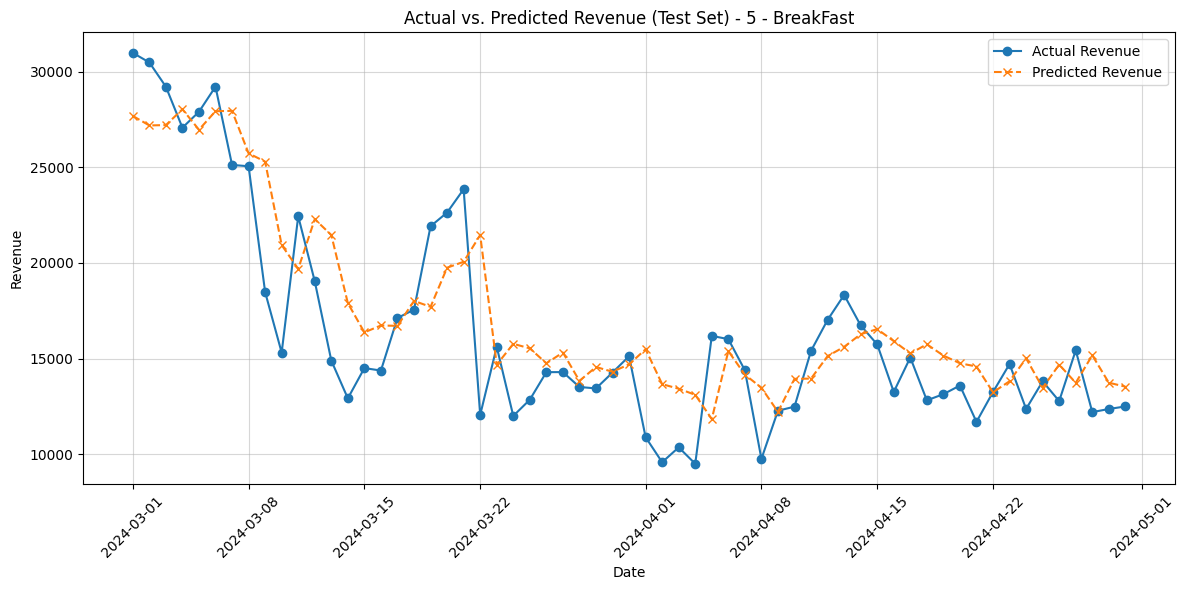

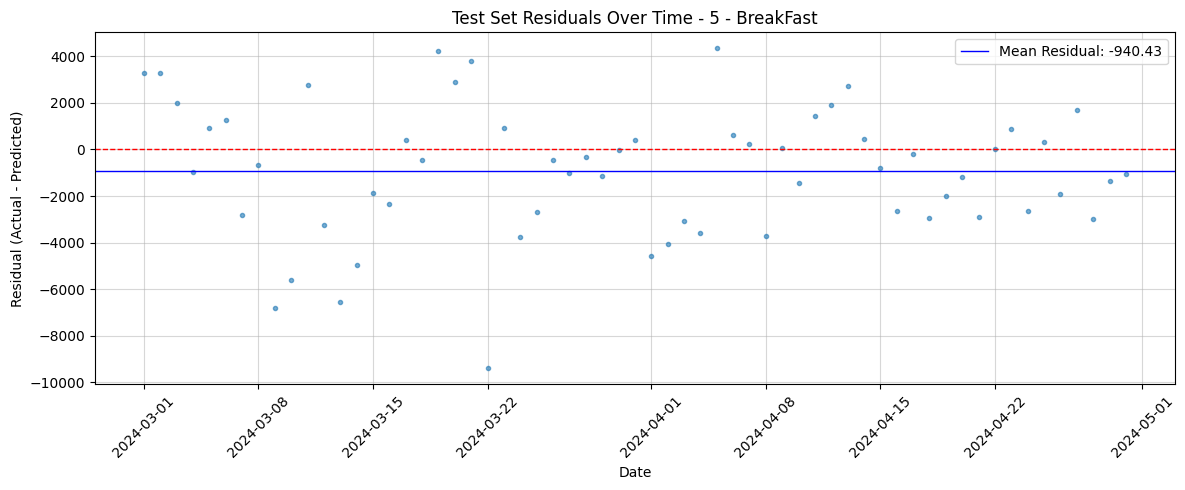


⚙️ Starting Grid Search (Restrictive) for 5 - Dinner
✅ Best parameters found: LR=0.01000, MD=3, Alpha=10.00. Min Avg CV RMSE: 5646.93

--- FINAL TEST SET RESULTS (5 - Dinner) ---
TEST RMSE: 9137.18, TEST MAPE: 52.25%


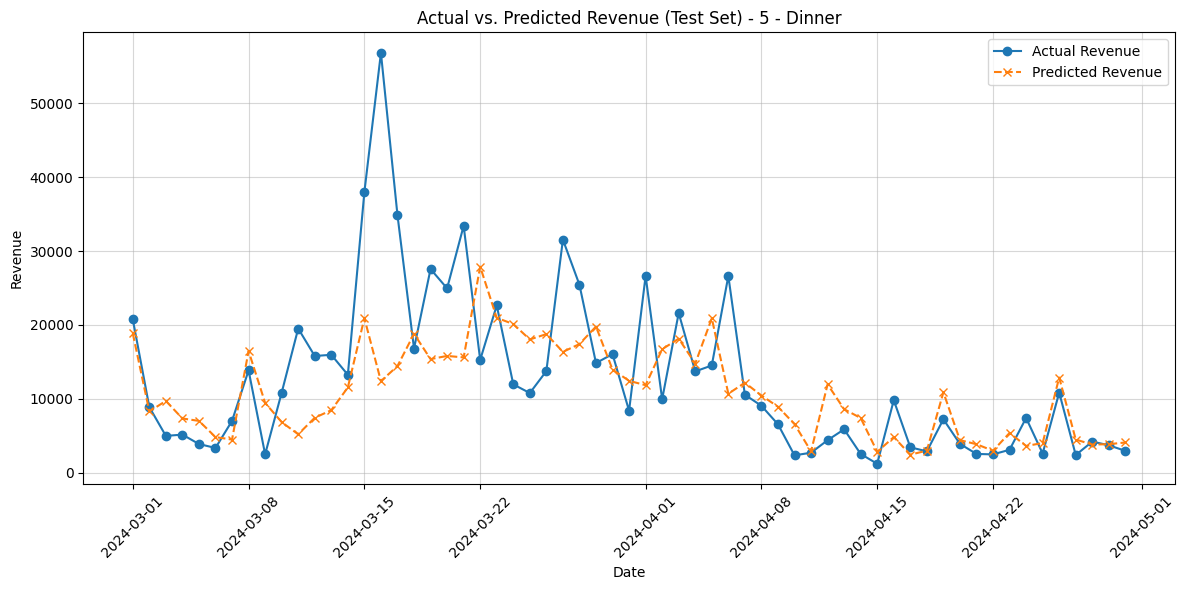

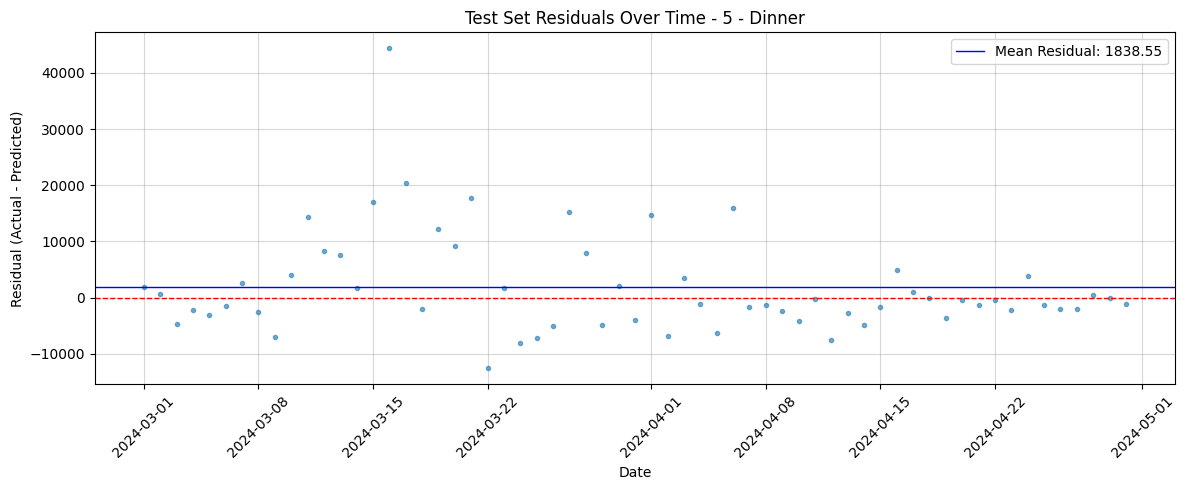


⚙️ Starting Grid Search (Restrictive) for 5 - Lunch
✅ Best parameters found: LR=0.01000, MD=5, Alpha=500.00. Min Avg CV RMSE: 2802.38

--- FINAL TEST SET RESULTS (5 - Lunch) ---
TEST RMSE: 3530.00, TEST MAPE: 9003097870.32%


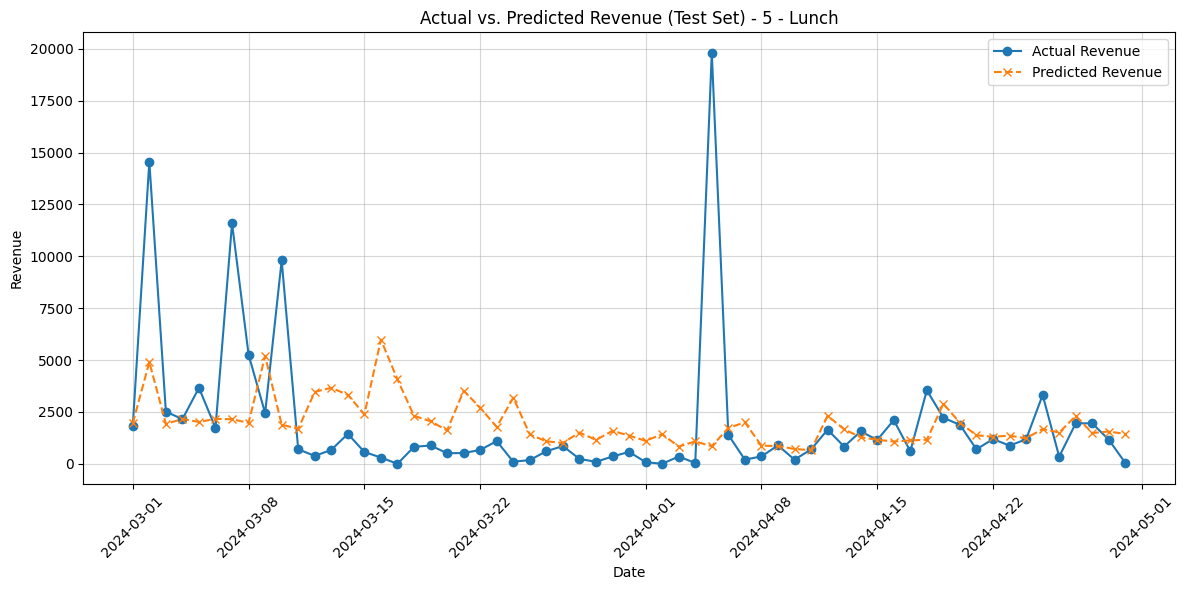

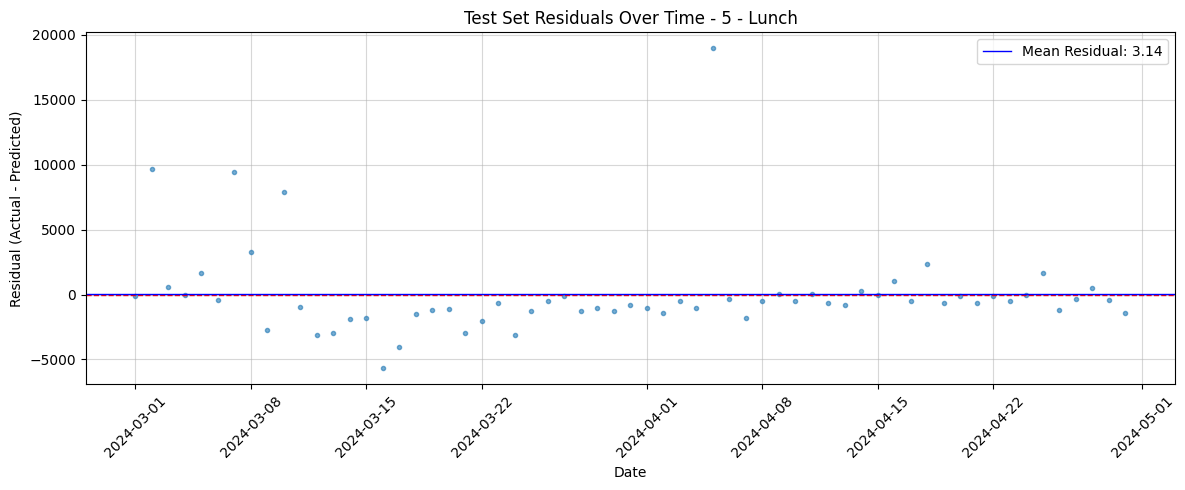


⚙️ Starting Grid Search (Restrictive) for 6 - BreakFast
✅ Best parameters found: LR=0.00500, MD=3, Alpha=500.00. Min Avg CV RMSE: 282.68

--- FINAL TEST SET RESULTS (6 - BreakFast) ---
TEST RMSE: 435.86, TEST MAPE: 8096178676.41%


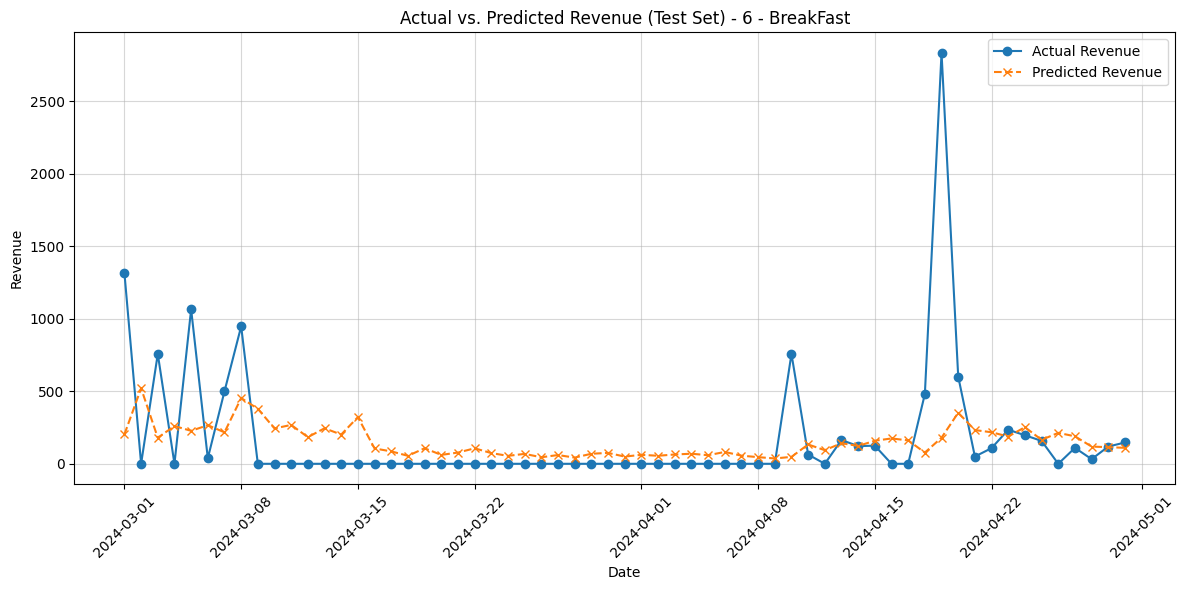

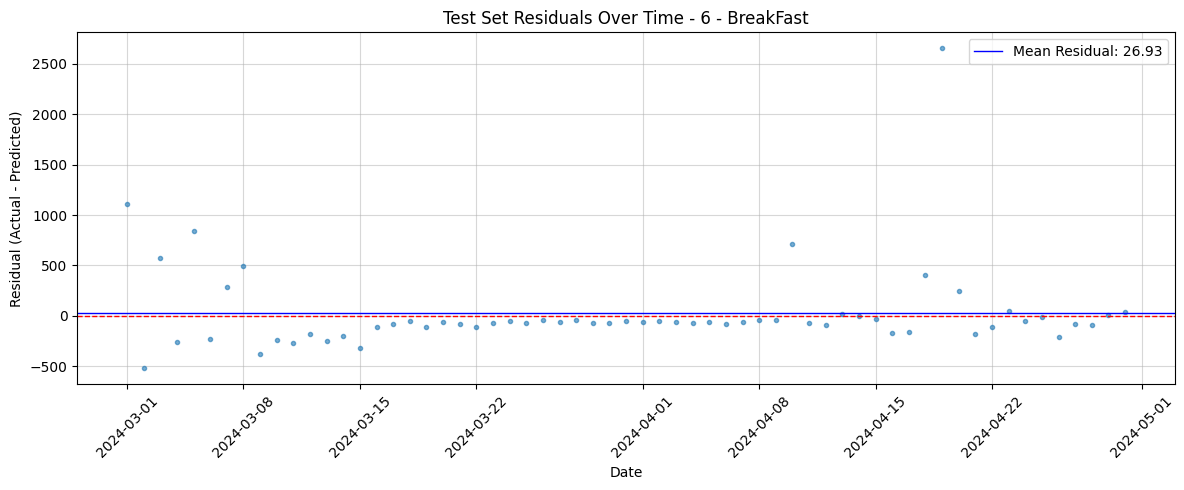


⚙️ Starting Grid Search (Restrictive) for 6 - Dinner
✅ Best parameters found: LR=0.00500, MD=3, Alpha=500.00. Min Avg CV RMSE: 2789.46

--- FINAL TEST SET RESULTS (6 - Dinner) ---
TEST RMSE: 7034.36, TEST MAPE: 6085540663.61%


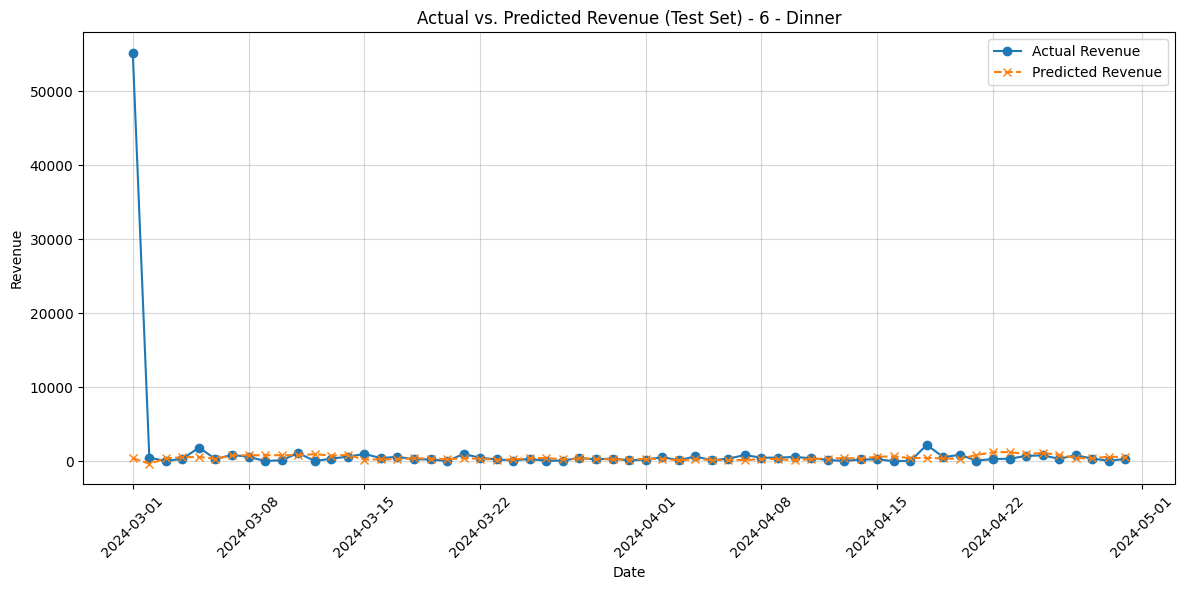

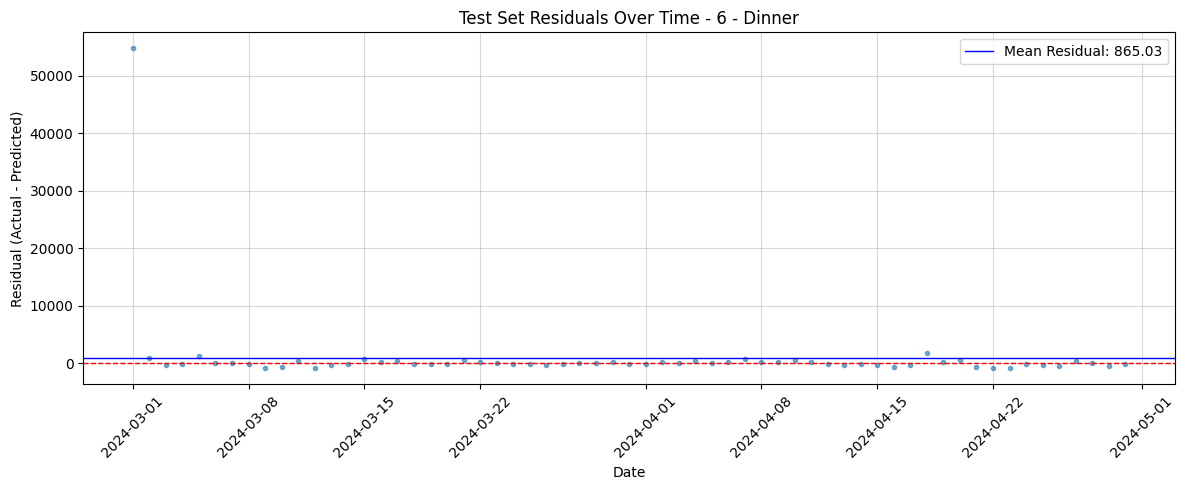


⚙️ Starting Grid Search (Restrictive) for 6 - Lunch
✅ Best parameters found: LR=0.00500, MD=3, Alpha=500.00. Min Avg CV RMSE: 525.29

--- FINAL TEST SET RESULTS (6 - Lunch) ---
TEST RMSE: 704.34, TEST MAPE: 19745703664.80%


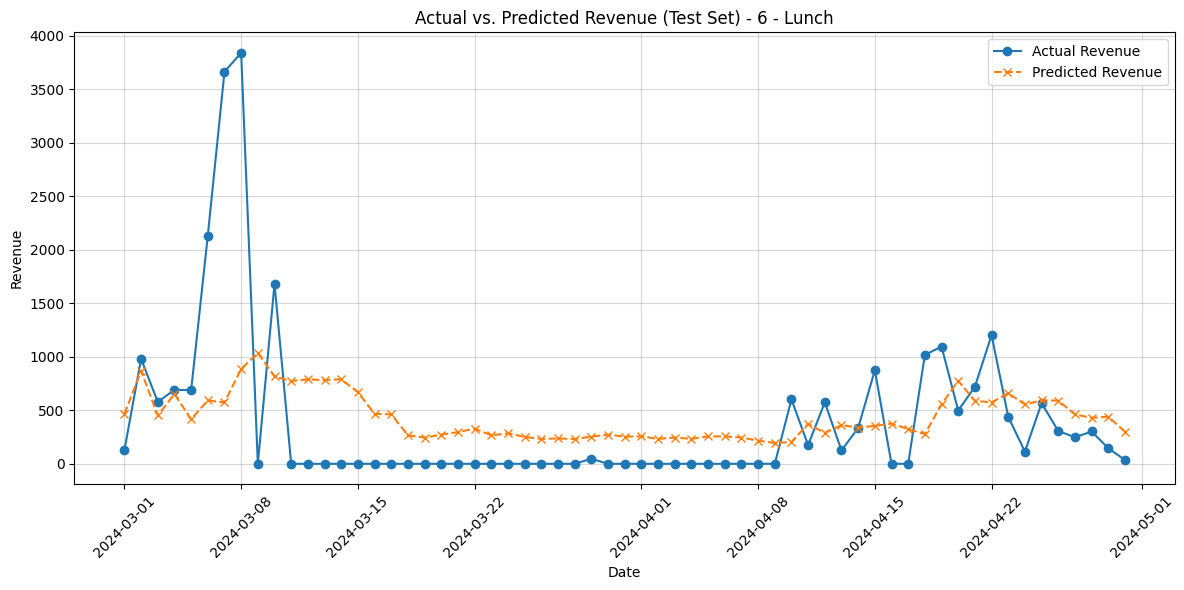

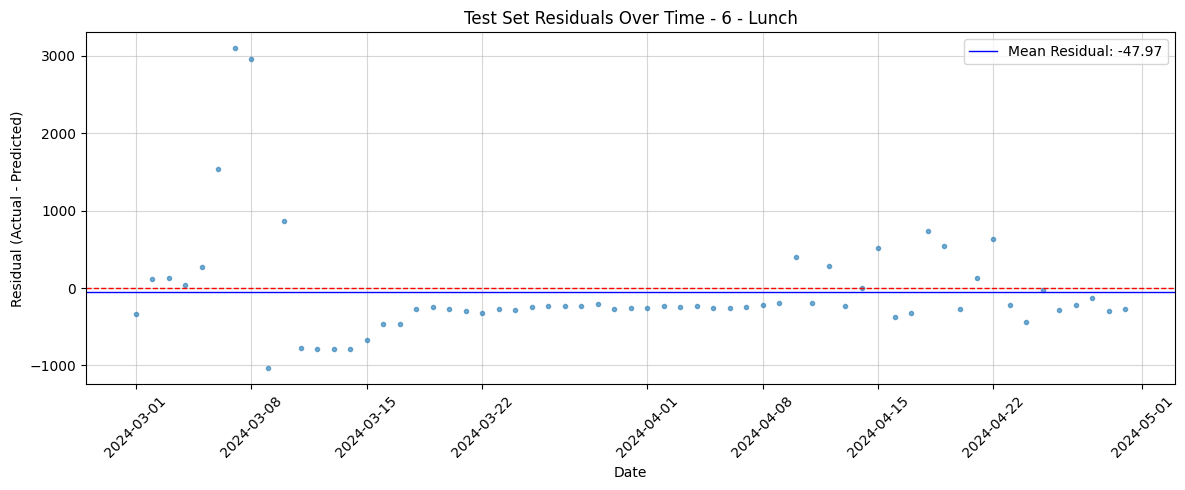


⚙️ Starting Grid Search (Restrictive) for 7 - BreakFast
✅ Best parameters found: LR=0.00500, MD=3, Alpha=500.00. Min Avg CV RMSE: 64.02

--- FINAL TEST SET RESULTS (7 - BreakFast) ---
TEST RMSE: 41.55, TEST MAPE: 2428887221.95%


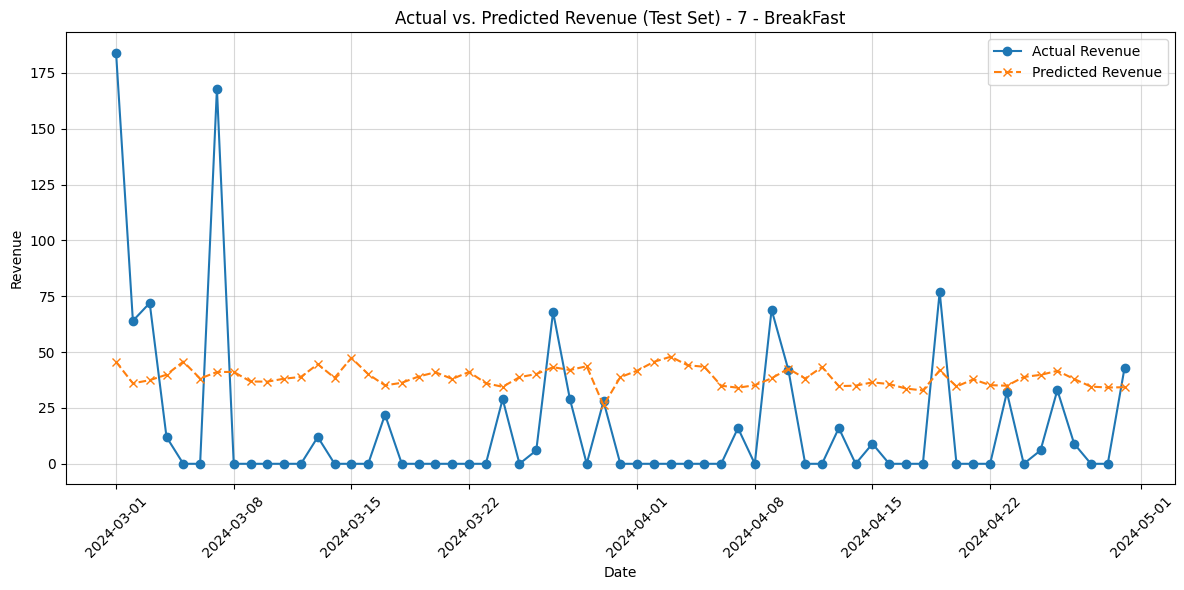

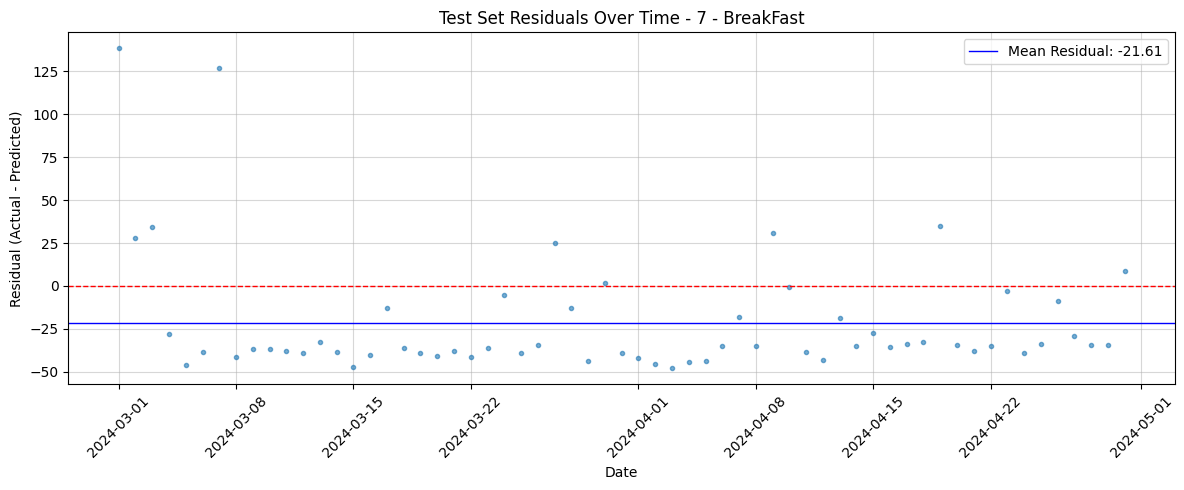


⚙️ Starting Grid Search (Restrictive) for 7 - Dinner
✅ Best parameters found: LR=0.01000, MD=3, Alpha=10.00. Min Avg CV RMSE: 80.34

--- FINAL TEST SET RESULTS (7 - Dinner) ---
TEST RMSE: 128.72, TEST MAPE: 1211541588.17%


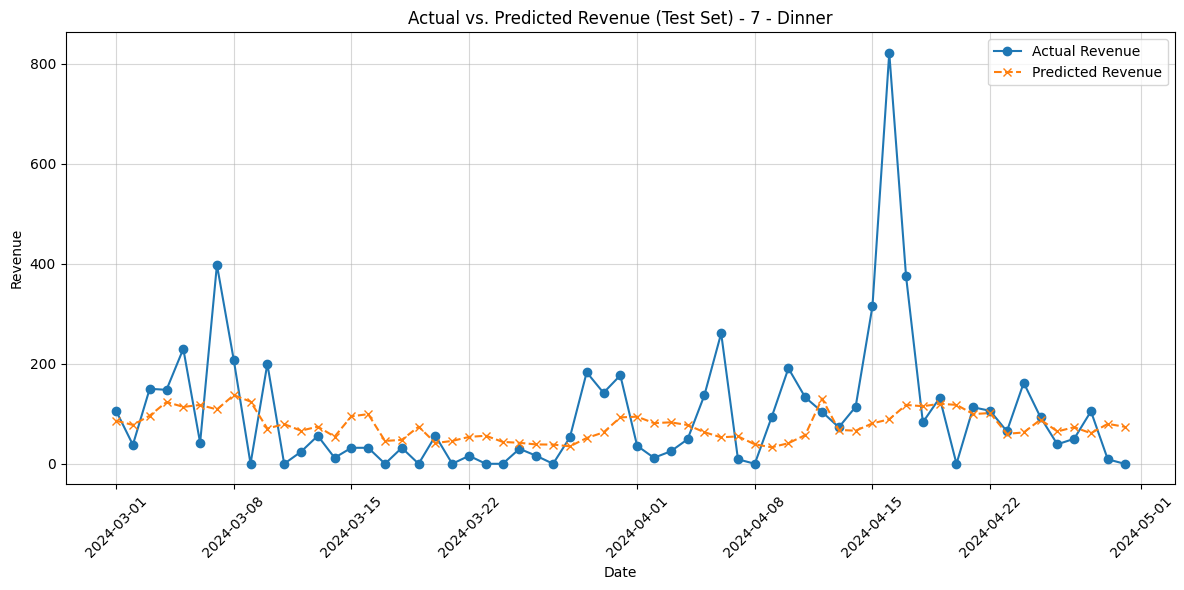

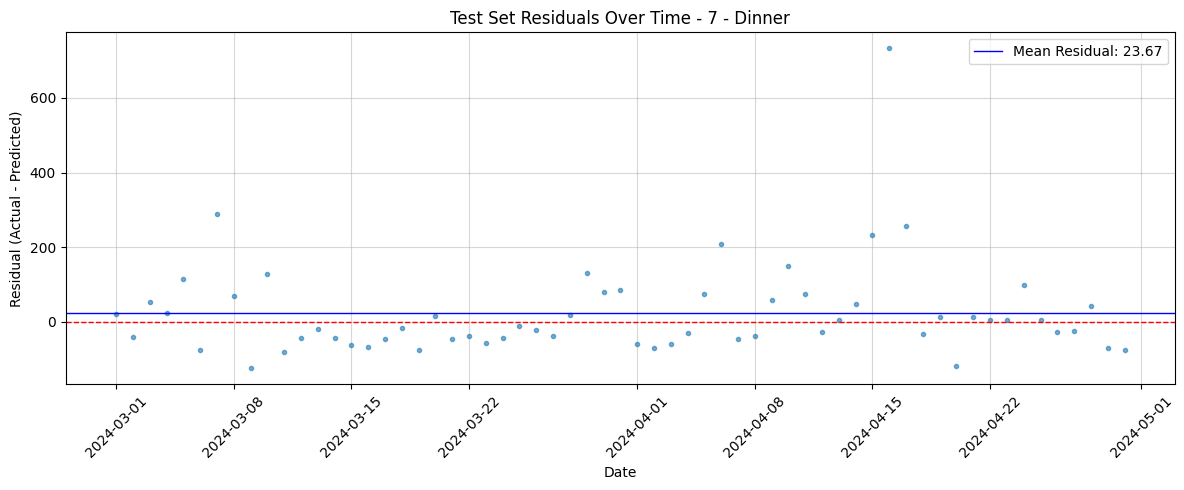


⚙️ Starting Grid Search (Restrictive) for 7 - Lunch
✅ Best parameters found: LR=0.00500, MD=3, Alpha=500.00. Min Avg CV RMSE: 50.09

--- FINAL TEST SET RESULTS (7 - Lunch) ---
TEST RMSE: 68.72, TEST MAPE: 1921111019.19%


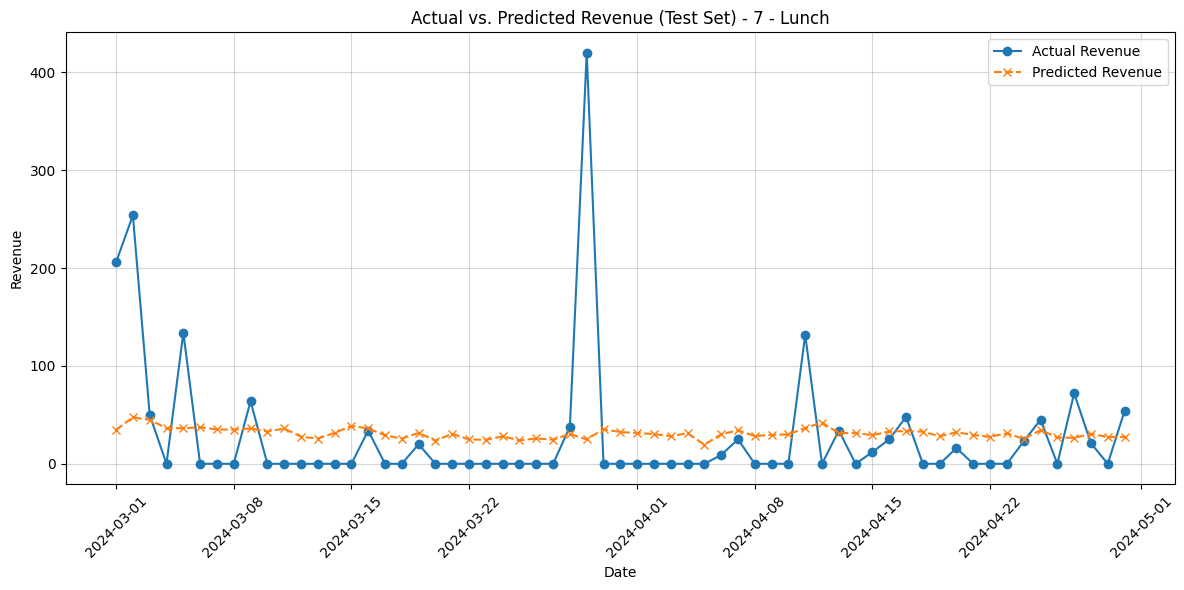

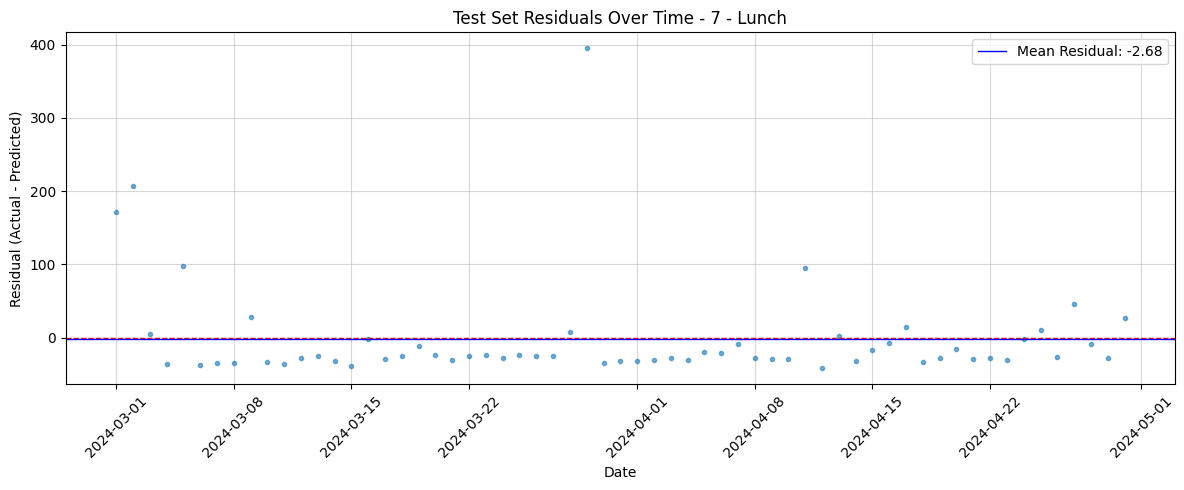


⚙️ Starting Grid Search (Restrictive) for 8 - BreakFast
✅ Best parameters found: LR=0.00500, MD=3, Alpha=500.00. Min Avg CV RMSE: 2537.05

--- FINAL TEST SET RESULTS (8 - BreakFast) ---
TEST RMSE: 3800.96, TEST MAPE: 25075239080.97%


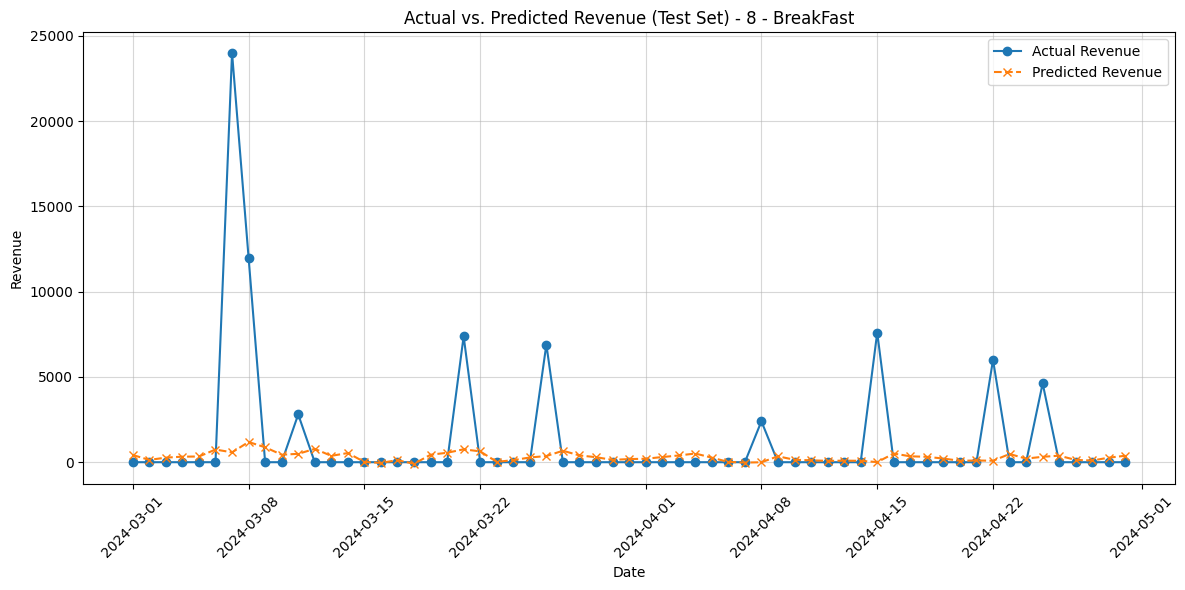

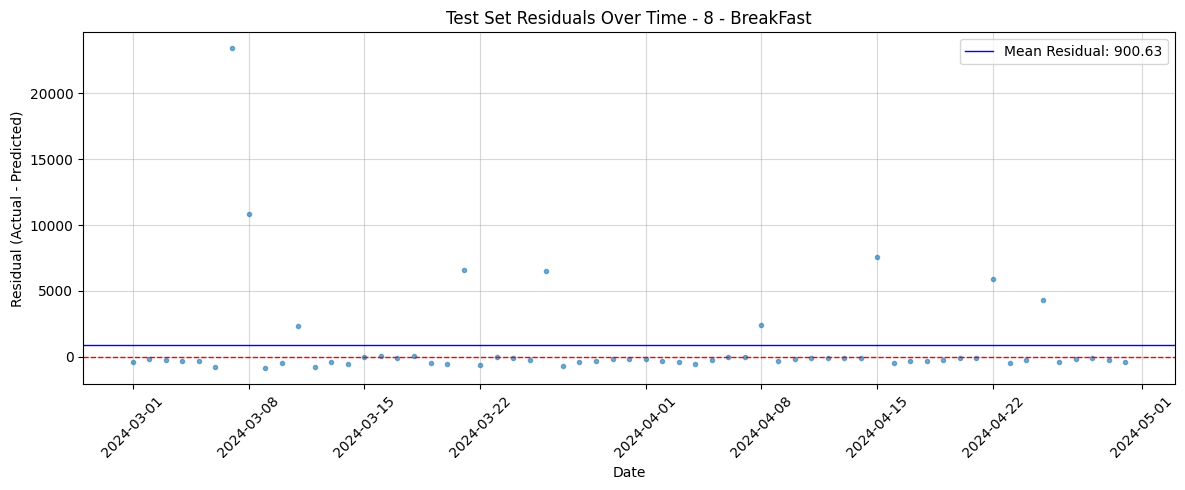


⚙️ Starting Grid Search (Restrictive) for 8 - Dinner
✅ Best parameters found: LR=0.01000, MD=5, Alpha=500.00. Min Avg CV RMSE: 18061.42

--- FINAL TEST SET RESULTS (8 - Dinner) ---
TEST RMSE: 23020.92, TEST MAPE: 525996319232.06%


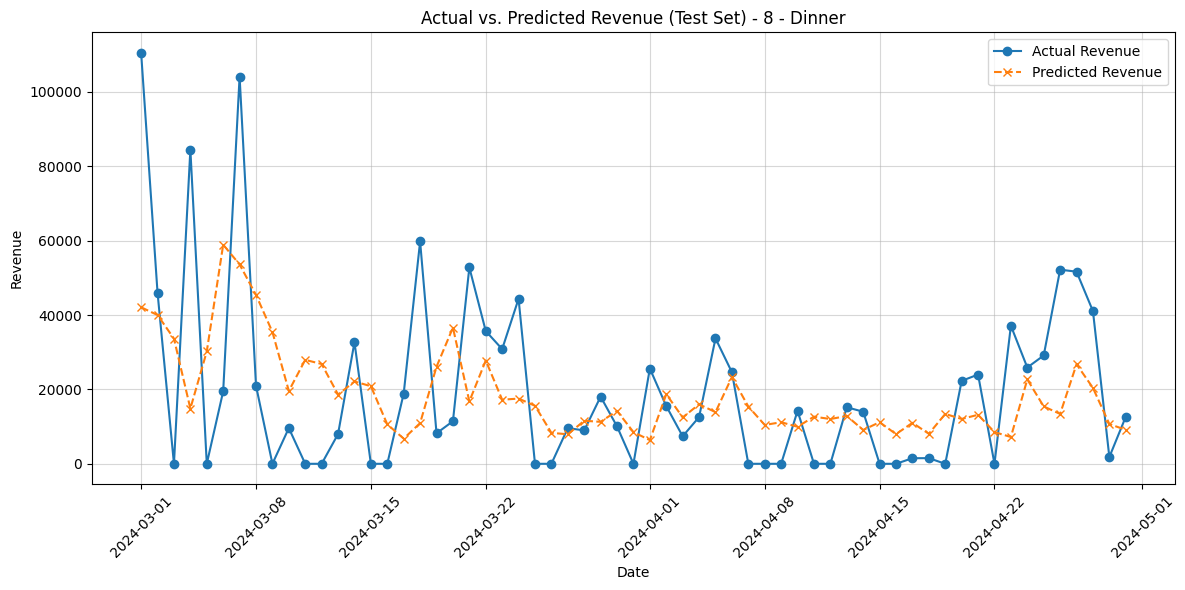

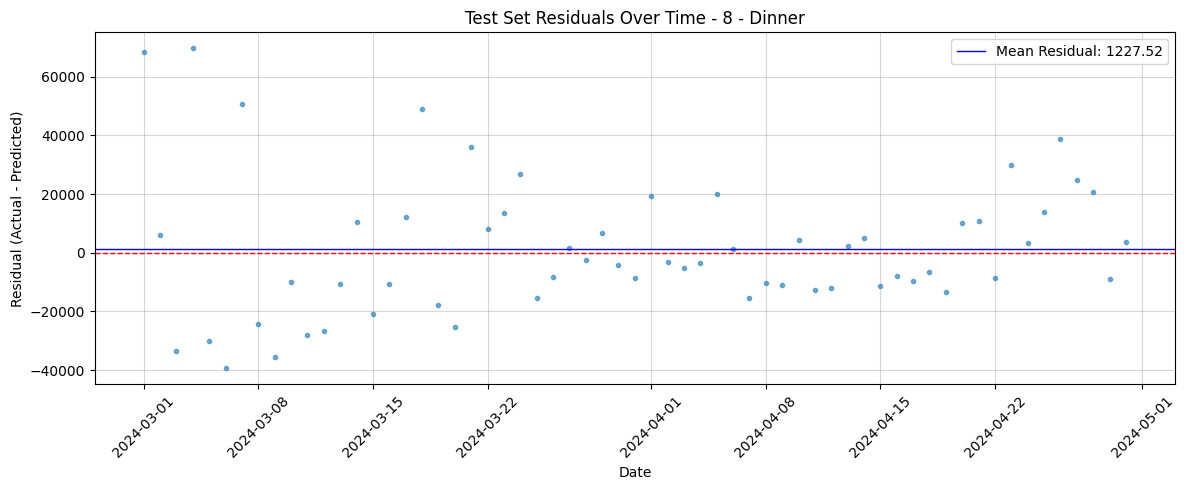


⚙️ Starting Grid Search (Restrictive) for 8 - Lunch
✅ Best parameters found: LR=0.01000, MD=3, Alpha=10.00. Min Avg CV RMSE: 14225.15

--- FINAL TEST SET RESULTS (8 - Lunch) ---
TEST RMSE: 16185.06, TEST MAPE: 348402363121.03%


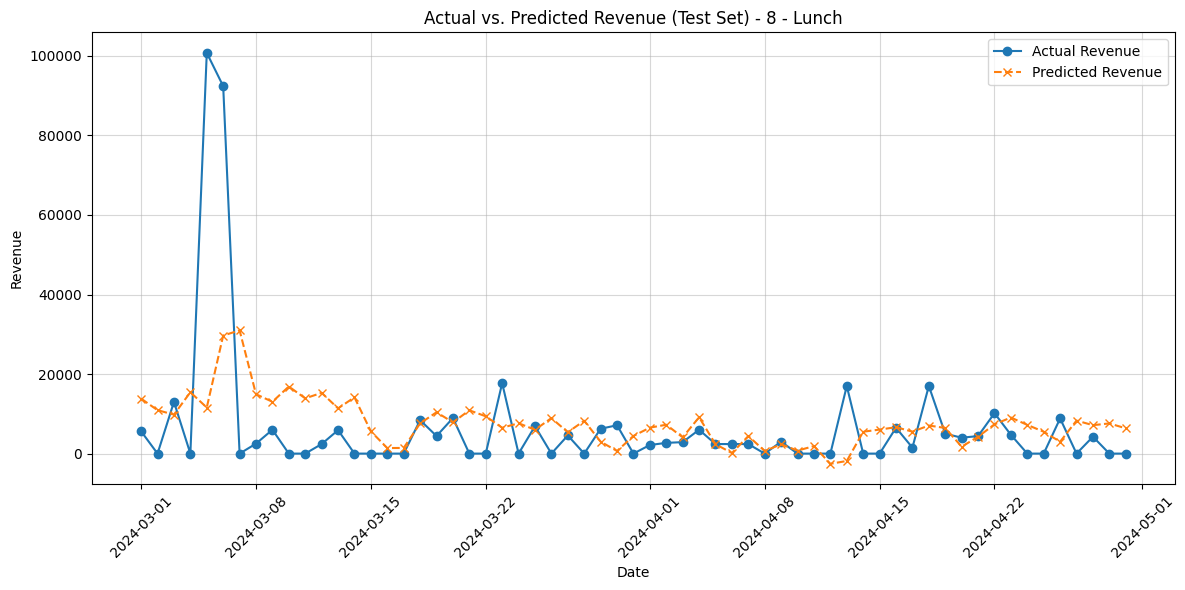

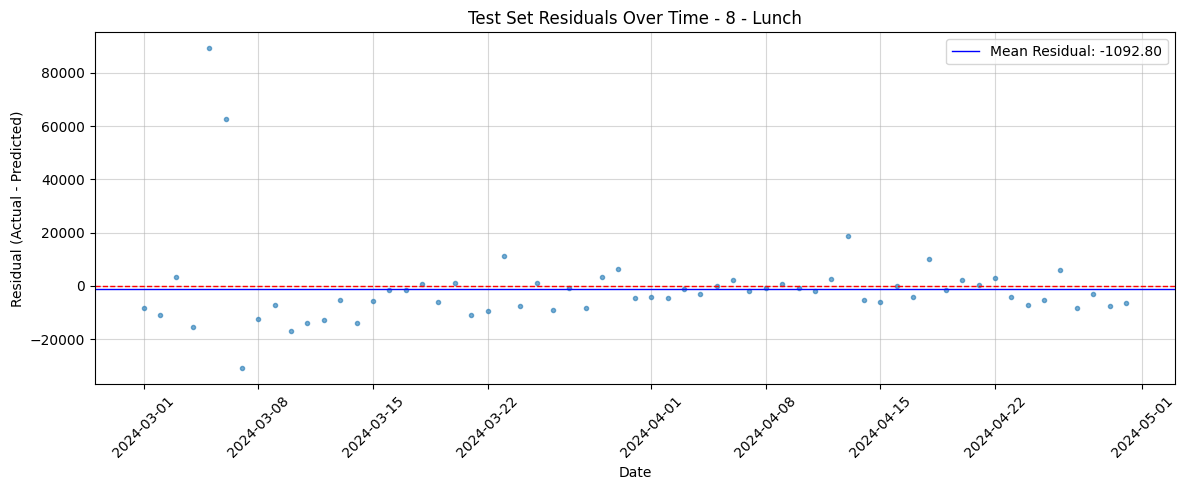


⚙️ Starting Grid Search (Restrictive) for 9 - BreakFast
✅ Best parameters found: LR=0.01000, MD=5, Alpha=0.01. Min Avg CV RMSE: 232.67

--- FINAL TEST SET RESULTS (9 - BreakFast) ---
TEST RMSE: 310.27, TEST MAPE: 2630402167.18%


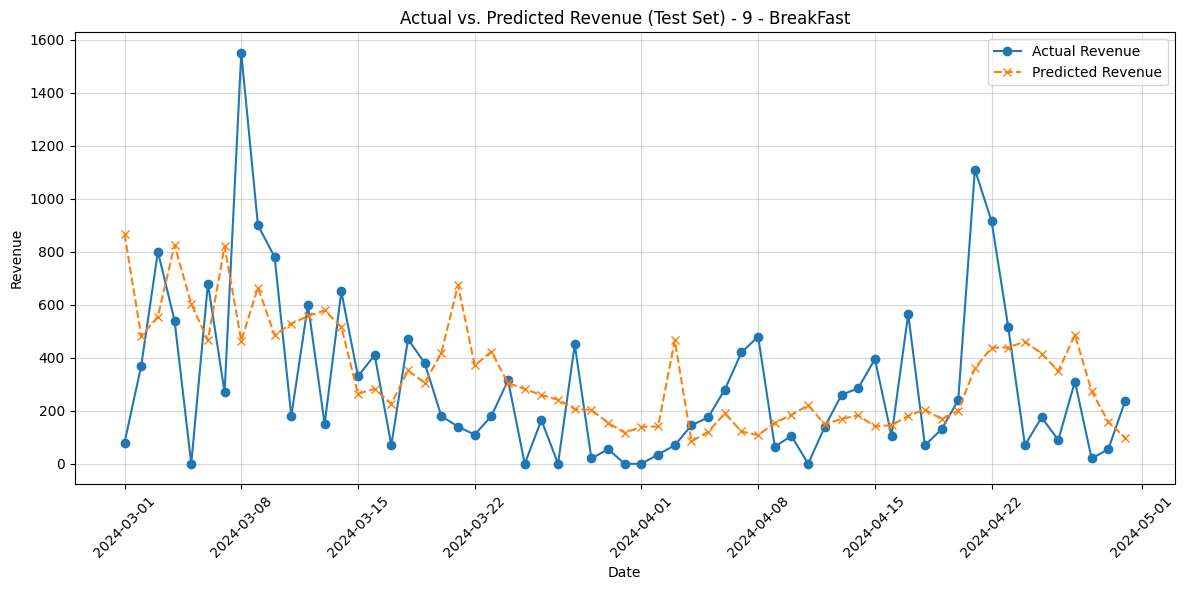

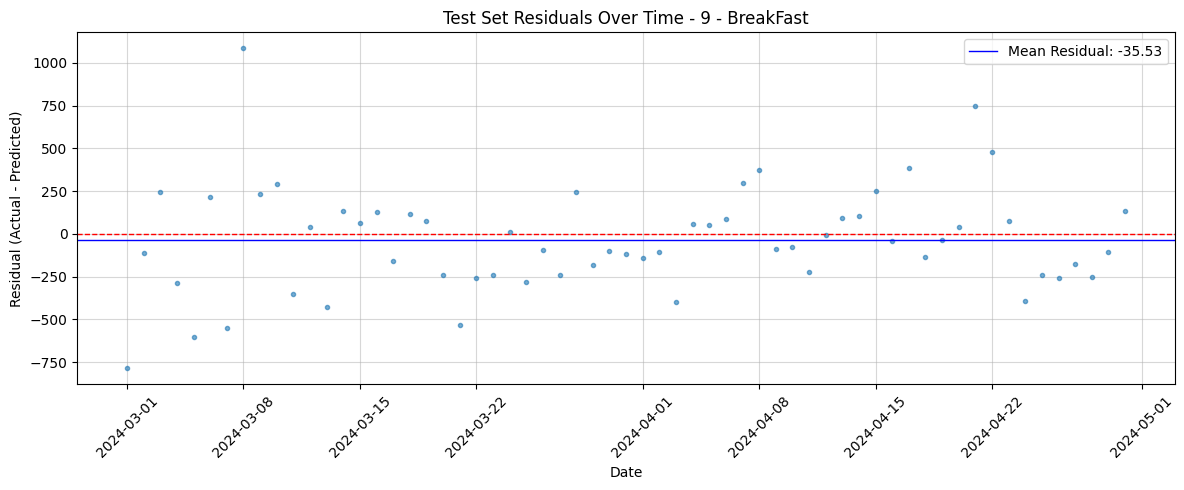


⚙️ Starting Grid Search (Restrictive) for 9 - Dinner
✅ Best parameters found: LR=0.00500, MD=3, Alpha=500.00. Min Avg CV RMSE: 90.37

--- FINAL TEST SET RESULTS (9 - Dinner) ---
TEST RMSE: 179.27, TEST MAPE: 3524726403.02%


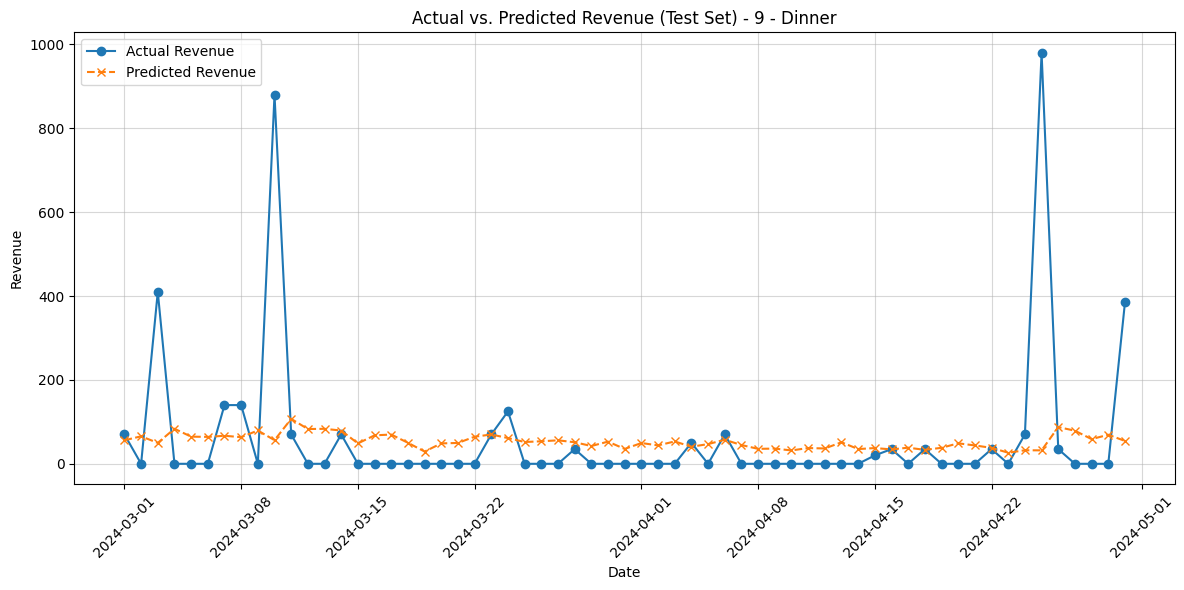

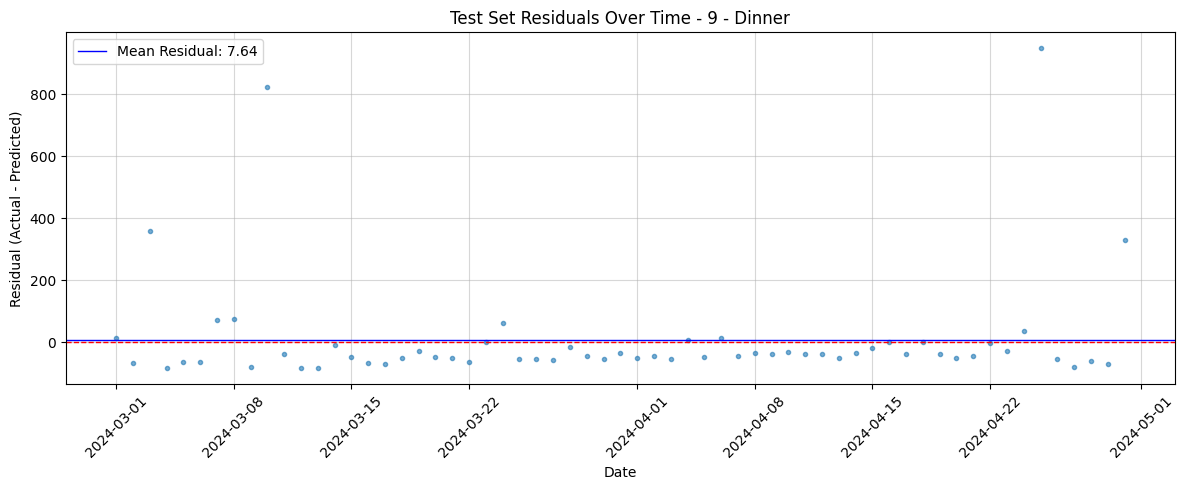


⚙️ Starting Grid Search (Restrictive) for 9 - Lunch
✅ Best parameters found: LR=0.00500, MD=3, Alpha=500.00. Min Avg CV RMSE: 197.14

--- FINAL TEST SET RESULTS (9 - Lunch) ---
TEST RMSE: 217.32, TEST MAPE: 4195059395.94%


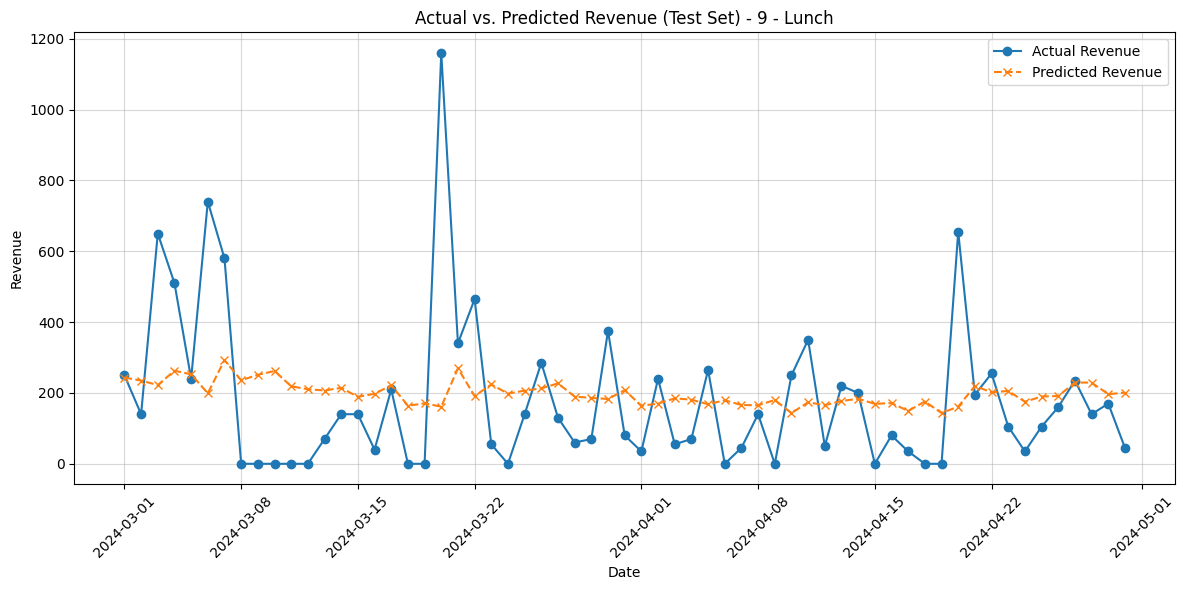

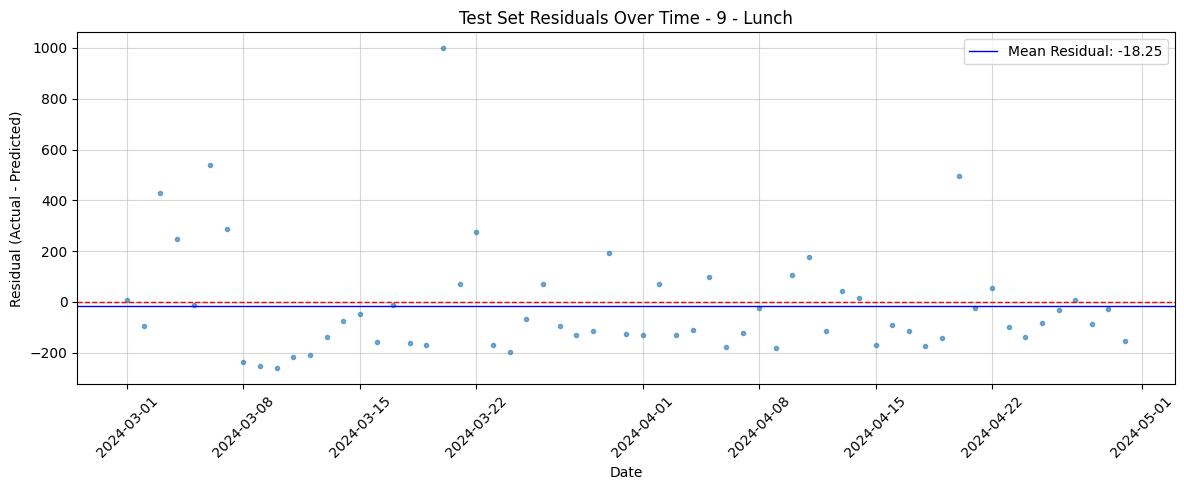



🥇 FINAL HYPERPARAMETER COMPARISON TABLE (Grid Search)
|   Center | Meal      | Method      |   Best_LR |   Best_MD |   Best_Alpha |   Avg_CV_RMSE |
|---------:|:----------|:------------|----------:|----------:|-------------:|--------------:|
|        1 | BreakFast | Grid Search |     0.01  |         3 |        10    |        885.57 |
|        1 | Dinner    | Grid Search |     0.01  |         3 |        10    |       1506.45 |
|        1 | Lunch     | Grid Search |     0.01  |         5 |         0.01 |        781.55 |
|        2 | BreakFast | Grid Search |     0.005 |         3 |       500    |        350.26 |
|        2 | Dinner    | Grid Search |     0.01  |         3 |        10    |        872.48 |
|        2 | Lunch     | Grid Search |     0.01  |         3 |        10    |        421.97 |
|        3 | BreakFast | Grid Search |     0.005 |         3 |       500    |        366.7  |
|        3 | Dinner    | Grid Search |     0.01  |         5 |         0.01 |       4301.47 |
|   

<Figure size 1400x700 with 0 Axes>

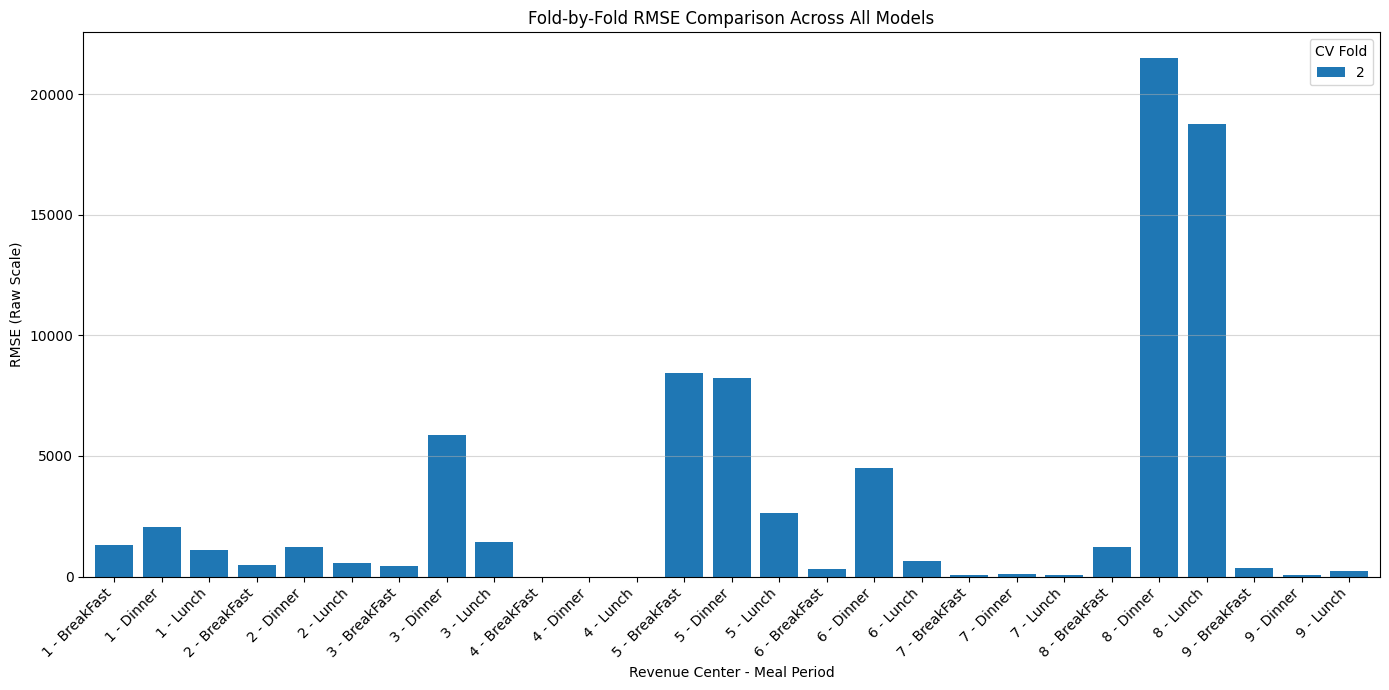

In [5]:
# --- Execute Training Across Centers ---

print("--- STARTING EXECUTION: Grid Search (Restrictive Alpha) ---")
try:
    if not os.path.exists(OUTPUT_FILE_NAME):
        raise FileNotFoundError(f"File not found at path: {OUTPUT_FILE_NAME}")
    xls = pd.ExcelFile(OUTPUT_FILE_NAME)
    REVENUE_CENTERS = xls.sheet_names
    print(f"✅ SUCCESS: Loaded {len(REVENUE_CENTERS)} revenue centers (sheets).")
except FileNotFoundError as e:
    print(f"❌ ERROR: File Not Found. Please check the path and ensure the file is uploaded/mounted. {e}")
    REVENUE_CENTERS = []
except Exception as e:
    print(f"❌ ERROR loading Excel file: {e}")
    REVENUE_CENTERS = []

for center_name in REVENUE_CENTERS:
    df_center = pd.read_excel(OUTPUT_FILE_NAME, sheet_name=center_name)
    df_center['Date'] = pd.to_datetime(df_center['Date'])
    required_cols = ['Date'] + TARGET_RAW_COLS
    if not all(col in df_center.columns for col in required_cols):
        print(f"❌ FAILED: Center {center_name} is missing essential columns. Skipping.")
        continue
    train_and_forecast_center(df_center, center_name)

# --- Post-Training Diagnostics ---
if REVENUE_CENTERS:
    print("\n\n" + "="*80)
    print("🥇 FINAL HYPERPARAMETER COMPARISON TABLE (Grid Search)")
    print("="*80)

    df_comp = pd.DataFrame(gs_final_comparison_results).sort_values(['Center', 'Meal', 'Avg_CV_RMSE'])

    df_comp['Best_Alpha'] = df_comp['Best_Alpha'].map('{:.2f}'.format)
    df_comp['Best_LR'] = df_comp['Best_LR'].map('{:.5f}'.format)
    df_comp['Avg_CV_RMSE'] = df_comp['Avg_CV_RMSE'].map('{:.2f}'.format)

    print(df_comp.to_markdown(index=False))

    print("\n--- VISUALIZING CROSS-VALIDATION ROBUSTNESS ---")
    plot_cv_rmse_comparison(cv_results_list)